In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Dataset, Subset
import numpy as np
import os
import glob
from PIL import Image
import copy
import random

# ==========================================
# 1. 基础配置
# ==========================================
# 检测 GPU
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🚀 Running on: {DEVICE}")

# 路径与参数
# 请确保这里是你真实的数据集路径
DATASET_ROOT = r'/root/autodl-tmp/exp2/data/NEU/IMAGES' 
BATCH_SIZE = 64
IMG_SIZE = 128
EPOCHS_PRETRAIN = 3   # 预训练轮数 (Stage 1)
EPOCHS_FED = 10       # 联邦微调轮数 (Stage 2)

# 固定随机种子 (保证结果可复现)
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if DEVICE == 'cuda':
        torch.cuda.manual_seed_all(seed)
set_seed(42)

# ==========================================
# 2. 数据处理与加载
# ==========================================
class NEUDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.file_paths[idx]).convert('RGB')
        except:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE)) # 容错
        
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

def load_data_split_by_factory():
    """
    全自动加载并拆分数据给3个工厂
    """
    print(f"\n📂 Scanning dataset from: {DATASET_ROOT}")
    CLASSES = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']
    class_to_idx = {c: i for i, c in enumerate(CLASSES)}
    
    all_files = []
    all_labels = []
    
    # 扫描文件
    if os.path.exists(DATASET_ROOT):
        for ext in ['*.jpg', '*.JPG', '*.bmp', '*.png']:
            for filepath in glob.glob(os.path.join(DATASET_ROOT, ext)):
                filename = os.path.basename(filepath).lower()
                for cls_name in CLASSES:
                    if cls_name in filename or (cls_name == 'scratches' and 'sc_' in filename):
                        all_files.append(filepath)
                        all_labels.append(class_to_idx[cls_name])
                        break
    
    # 如果没数据，自动生成假数据跑通流程
    if len(all_files) == 0:
        print("⚠️ Warning: No images found. Generating FAKE data for simulation.")
        all_files = [f"fake_{i}.jpg" for i in range(600)]
        all_labels = [i % 6 for i in range(600)]

    print(f"✅ Total images loaded: {len(all_files)}")

    # 数据增强
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    
    # 按类别拆分数据孤岛
    # 工厂 A: 只有 0, 1 类
    idx_A = [i for i, l in enumerate(all_labels) if l in [0, 1]]
    ds_A = NEUDataset([all_files[i] for i in idx_A], [all_labels[i] for i in idx_A], transform)
    
    # 工厂 B: 只有 2, 3 类
    idx_B = [i for i, l in enumerate(all_labels) if l in [2, 3]]
    ds_B = NEUDataset([all_files[i] for i in idx_B], [all_labels[i] for i in idx_B], transform)
    
    # 工厂 C: 只有 4, 5 类
    idx_C = [i for i, l in enumerate(all_labels) if l in [4, 5]]
    ds_C = NEUDataset([all_files[i] for i in idx_C], [all_labels[i] for i in idx_C], transform)
    
    # 测试集 (随机抽样验证全局能力)
    test_idx = np.random.choice(len(all_files), min(300, len(all_files)), replace=False)
    ds_test = NEUDataset([all_files[i] for i in test_idx], [all_labels[i] for i in test_idx], transform)
    
    print(f"🏭 Factory A Data: {len(ds_A)}")
    print(f"🏭 Factory B Data: {len(ds_B)}")
    print(f"🏭 Factory C Data: {len(ds_C)}")
    
    return DataLoader(ds_A, BATCH_SIZE, shuffle=True), \
           DataLoader(ds_B, BATCH_SIZE, shuffle=True), \
           DataLoader(ds_C, BATCH_SIZE, shuffle=True), \
           DataLoader(ds_test, BATCH_SIZE, shuffle=False)

# ==========================================
# 3. 模型定义 (多项式激活)
# ==========================================
class DynamicAct(nn.Module):
    def __init__(self):
        super().__init__()
        # 固定使用多项式拟合参数
        self.register_buffer('a', torch.tensor(0.17))
        self.register_buffer('b', torch.tensor(0.5))
        self.register_buffer('c', torch.tensor(0.12))
    def forward(self, x):
        return self.a * (x**2) + self.b * x + self.c

class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        # 前半部分特征提取
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            DynamicAct(),
            nn.MaxPool2d(2), 
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            DynamicAct(),
            nn.MaxPool2d(2)  
        )
    def forward(self, x):
        return self.features(x)

class ServerModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 后半部分 + 分类头
        self.classifier = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            DynamicAct(),
            nn.AdaptiveAvgPool2d((1, 1)), 
            nn.Flatten(),
            nn.Linear(128, num_classes) 
        )
    def forward(self, x):
        return self.classifier(x)

# ==========================================
# 4. 安全防御机制 (梯度稀疏化 + 差分隐私)
# ==========================================
def apply_gradient_defense(grad_tensor, prune_ratio=0.5, noise_std=1e-3):
    """
    防御逻辑：扔掉 50% 小梯度 + 加噪声 -> 防止云端反推图片
    """
    if grad_tensor is None: return None
    grad = grad_tensor.detach().clone()
    
    # 1. 稀疏化
    k = int(grad.numel() * (1 - prune_ratio))
    if k > 0:
        threshold = torch.kthvalue(grad.abs().flatten(), grad.numel() - k + 1).values
        mask = grad.abs() >= threshold
        grad = grad * mask
        
    # 2. 加噪
    if noise_std > 0:
        noise = torch.randn_like(grad) * noise_std
        grad = grad + noise
    return grad

# ==========================================
# 5. 核心实验流程
# ==========================================
def run_full_experiment():
    print("==================================================")
    print("🚀 启动终极实验 (Pro Mode)：全量预训练 + 长时联邦")
    print("==================================================")
    
    # --- 1. 参数升级 ---
    # 增加轮数，确保收敛
    EPOCHS_PRETRAIN = 5     # 原来是 3
    EPOCHS_FED = 30         # 原来是 10 (Non-IID 需要更多轮次)
    
    # --- A. 初始化全局模型 ---
    print("\n[Init] Building Models...")
    global_client = ClientModel().to(DEVICE)
    global_server = ServerModel(num_classes=10).to(DEVICE)
    
    # --- B. Stage 1: 全量云端预训练 (CIFAR-10) ---
    print("\n☁️ [Stage 1] Pre-training on FULL CIFAR-10...")
    
    transform_cifar = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    
    try:
        cifar_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_cifar)
        
        # 🔥 修改点 1：使用全量数据 (50,000张)，不再Subset 🔥
        # cifar_subset = Subset(cifar_set, list(range(2000))) <--- 删除这行
        cifar_loader = DataLoader(cifar_set, batch_size=128, shuffle=True, num_workers=4) # num_workers加速
        
        opt_c = optim.AdamW(global_client.parameters(), lr=1e-3)
        opt_s = optim.AdamW(global_server.parameters(), lr=1e-3)
        criterion = nn.CrossEntropyLoss()
        
        for epoch in range(1, EPOCHS_PRETRAIN + 1):
            global_client.train(); global_server.train()
            total_loss = 0
            # 加个简单的计数器看进度
            batch_count = 0
            for imgs, labels in cifar_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                opt_c.zero_grad(); opt_s.zero_grad()
                
                z = global_client(imgs)
                logits = global_server(z)
                loss = criterion(logits, labels)
                
                loss.backward()
                opt_s.step(); opt_c.step()
                total_loss += loss.item()
                batch_count += 1
                
            avg_loss = total_loss / len(cifar_loader)
            print(f"   Epoch {epoch} (Pre-train) | Loss: {avg_loss:.4f}")
            
    except Exception as e:
        print(f"❌ CIFAR-10 Error: {e}")

    print("✅ Pre-training Finished. (Feature Extractor Ready!)")

    # --- C. 准备 Stage 2 ---
    print("\n🏭 [Stage 2] Preparing Federated Learning (Non-IID)...")
    
    # 换头
    global_server.classifier[5] = nn.Linear(128, 6).to(DEVICE)
    
    # 分发模型
    client_A = copy.deepcopy(global_client)
    client_B = copy.deepcopy(global_client)
    client_C = copy.deepcopy(global_client)
    server = global_server 
    
    # 数据准备
    loader_A, loader_B, loader_C, loader_test = load_data_split_by_factory()
    
    # 优化器
    lr_fed = 1e-4
    opt_A = optim.AdamW(client_A.parameters(), lr=lr_fed)
    opt_B = optim.AdamW(client_B.parameters(), lr=lr_fed)
    opt_C = optim.AdamW(client_C.parameters(), lr=lr_fed)
    opt_S = optim.AdamW(server.parameters(), lr=lr_fed)
    
    criterion = nn.CrossEntropyLoss()
    
    # --- D. 联邦训练循环 ---
    print(f"\n🔄 Starting Federated Rounds (Total {EPOCHS_FED})...")
    
    history_acc = []
    
    for epoch in range(1, EPOCHS_FED + 1):
        
        # --- 本地训练 ---
        # (这里代码逻辑不用变，复用之前的 train_factory_step)
        def train_factory_step(c_model, c_opt, loader):
            c_model.train(); server.train()
            losses = []
            for imgs, labels in loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                c_opt.zero_grad(); opt_S.zero_grad()
                z = c_model(imgs)
                z_payload = z.detach().clone(); z_payload.requires_grad_(True)
                logits = server(z_payload)
                loss = criterion(logits, labels)
                loss.backward()
                
                # 🛡️ 保持防御开启！这是你的亮点
                raw_grad = z_payload.grad
                safe_grad = apply_gradient_defense(raw_grad, prune_ratio=0.5, noise_std=1e-3)
                
                z.backward(safe_grad)
                c_opt.step(); opt_S.step()
                losses.append(loss.item())
            return sum(losses)/len(losses) if len(losses) > 0 else 0

        l_A = train_factory_step(client_A, opt_A, loader_A)
        l_B = train_factory_step(client_B, opt_B, loader_B)
        l_C = train_factory_step(client_C, opt_C, loader_C)
        
        # --- 联邦聚合 ---
        with torch.no_grad():
            w_avg = global_client.state_dict()
            w_A = client_A.state_dict()
            w_B = client_B.state_dict()
            w_C = client_C.state_dict()
            for k in w_avg.keys():
                w_avg[k] = (w_A[k] + w_B[k] + w_C[k]) / 3.0
            global_client.load_state_dict(w_avg)
            client_A.load_state_dict(w_avg)
            client_B.load_state_dict(w_avg)
            client_C.load_state_dict(w_avg)
            
        # --- 全局测试 ---
        if epoch % 1 == 0: # 每轮都测
            global_client.eval(); server.eval()
            correct = 0; total = 0
            with torch.no_grad():
                for imgs, labels in loader_test:
                    imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                    z = global_client(imgs)
                    logits = server(z)
                    _, pred = torch.max(logits, 1)
                    correct += (pred == labels).sum().item()
                    total += labels.size(0)
            acc = 100 * correct / total if total > 0 else 0
            history_acc.append(acc)
            
            print(f"   Round {epoch} | Loss: {l_A:.2f}/{l_B:.2f}/{l_C:.2f} | 🏆 Acc: {acc:.2f}%")

    print(f"\n✅ Pro Experiment Finished. Best Accuracy: {max(history_acc):.2f}%")

# 运行升级版实验
run_full_experiment()

🚀 Running on: cuda
🚀 启动终极实验 (Pro Mode)：全量预训练 + 长时联邦

[Init] Building Models...

☁️ [Stage 1] Pre-training on FULL CIFAR-10...
Files already downloaded and verified
   Epoch 1 (Pre-train) | Loss: 1.7833
   Epoch 2 (Pre-train) | Loss: 1.5362
   Epoch 3 (Pre-train) | Loss: 1.4368
   Epoch 4 (Pre-train) | Loss: 1.3787
   Epoch 5 (Pre-train) | Loss: 1.3334
✅ Pre-training Finished. (Feature Extractor Ready!)

🏭 [Stage 2] Preparing Federated Learning (Non-IID)...

📂 Scanning dataset from: /root/autodl-tmp/exp2/data/NEU/IMAGES
✅ Total images loaded: 1800
🏭 Factory A Data: 600
🏭 Factory B Data: 600
🏭 Factory C Data: 600

🔄 Starting Federated Rounds (Total 30)...
   Round 1 | Loss: 1.96/1.57/2.17 | 🏆 Acc: 20.33%
   Round 2 | Loss: 1.67/1.45/1.97 | 🏆 Acc: 33.33%
   Round 3 | Loss: 1.49/1.39/1.83 | 🏆 Acc: 37.00%
   Round 4 | Loss: 1.34/1.34/1.71 | 🏆 Acc: 46.00%
   Round 5 | Loss: 1.21/1.31/1.61 | 🏆 Acc: 54.00%
   Round 6 | Loss: 1.12/1.28/1.55 | 🏆 Acc: 55.67%
   Round 7 | Loss: 1.03/1.25/1.49 | 🏆 

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Dataset, Subset
import numpy as np
import os
import glob
from PIL import Image
import copy
import random

# ==========================================
# 1. 基础配置
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🚀 Running on: {DEVICE}")

DATASET_ROOT = r'/root/autodl-tmp/exp2/data/NEU/IMAGES' 
BATCH_SIZE = 64
IMG_SIZE = 128
EPOCHS_PRETRAIN = 5     # 预训练 5 轮 (足够学会通用特征)
EPOCHS_FED = 30         # 联邦 30 轮
LOCAL_EPOCHS = 3        # 🔥 关键：每轮联邦，本地多练 3 次

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if DEVICE == 'cuda':
        torch.cuda.manual_seed_all(seed)
set_seed(42)

# ==========================================
# 2. 数据处理与加载
# ==========================================
# (保持与之前一致的数据加载逻辑)
class NEUDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.file_paths)
    def __getitem__(self, idx):
        try: img = Image.open(self.file_paths[idx]).convert('RGB')
        except: img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

def load_data_split_by_factory():
    print(f"\n📂 Scanning dataset from: {DATASET_ROOT}")
    CLASSES = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']
    class_to_idx = {c: i for i, c in enumerate(CLASSES)}
    all_files = []; all_labels = []
    
    if os.path.exists(DATASET_ROOT):
        for ext in ['*.jpg', '*.JPG', '*.bmp', '*.png']:
            for filepath in glob.glob(os.path.join(DATASET_ROOT, ext)):
                filename = os.path.basename(filepath).lower()
                for cls_name in CLASSES:
                    if cls_name in filename or (cls_name == 'scratches' and 'sc_' in filename):
                        all_files.append(filepath); all_labels.append(class_to_idx[cls_name])
                        break
    if len(all_files) == 0: # 假数据容错
        all_files = [f"fake_{i}.jpg" for i in range(600)]
        all_labels = [i % 6 for i in range(600)]

    transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    
    # 拆分孤岛
    idx_A = [i for i, l in enumerate(all_labels) if l in [0, 1]]
    idx_B = [i for i, l in enumerate(all_labels) if l in [2, 3]]
    idx_C = [i for i, l in enumerate(all_labels) if l in [4, 5]]
    
    ds_A = NEUDataset([all_files[i] for i in idx_A], [all_labels[i] for i in idx_A], transform)
    ds_B = NEUDataset([all_files[i] for i in idx_B], [all_labels[i] for i in idx_B], transform)
    ds_C = NEUDataset([all_files[i] for i in idx_C], [all_labels[i] for i in idx_C], transform)
    
    # 全局测试集
    test_idx = np.random.choice(len(all_files), min(300, len(all_files)), replace=False)
    ds_test = NEUDataset([all_files[i] for i in test_idx], [all_labels[i] for i in test_idx], transform)
    
    print(f"🏭 Factory A: {len(ds_A)} | B: {len(ds_B)} | C: {len(ds_C)}")
    return DataLoader(ds_A, BATCH_SIZE, shuffle=True), DataLoader(ds_B, BATCH_SIZE, shuffle=True), DataLoader(ds_C, BATCH_SIZE, shuffle=True), DataLoader(ds_test, BATCH_SIZE, shuffle=False)

# ==========================================
# 3. 模型定义
# ==========================================
class DynamicAct(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer('a', torch.tensor(0.17))
        self.register_buffer('b', torch.tensor(0.5))
        self.register_buffer('c', torch.tensor(0.12))
    def forward(self, x): return self.a * (x**2) + self.b * x + self.c

class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), DynamicAct(), nn.MaxPool2d(2), 
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), DynamicAct(), nn.MaxPool2d(2)
        )
    def forward(self, x): return self.features(x)

class ServerModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), DynamicAct(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Linear(128, num_classes)
        )
    def forward(self, x): return self.classifier(x)

# ==========================================
# 4. 终极无防御对照实验
# ==========================================
def run_strict_control_experiment():
    print("==================================================")
    print("🚀 启动严格对照实验：架构完全不变，仅移除防御")
    print("   (控制变量：Pre-train=5, Fed_Rounds=30, Local_Ep=1)")
    print("==================================================")
    
    # 保持参数完全一致
    EPOCHS_PRETRAIN = 5
    EPOCHS_FED = 30
    
    # --- A. 初始化 ---
    print("\n[Init] Building Models...")
    global_client = ClientModel().to(DEVICE)
    global_server = ServerModel(num_classes=10).to(DEVICE)
    
    # --- B. Stage 1: 全量预训练 (和之前完全一样) ---
    print("\n☁️ [Stage 1] Pre-training on FULL CIFAR-10...")
    transform_cifar = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    try:
        cifar_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_cifar)
        cifar_loader = DataLoader(cifar_set, batch_size=128, shuffle=True, num_workers=4)
        opt_c = optim.AdamW(global_client.parameters(), lr=1e-3)
        opt_s = optim.AdamW(global_server.parameters(), lr=1e-3)
        criterion = nn.CrossEntropyLoss()
        
        for epoch in range(1, EPOCHS_PRETRAIN + 1):
            global_client.train(); global_server.train()
            total_loss = 0
            for imgs, labels in cifar_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                opt_c.zero_grad(); opt_s.zero_grad()
                z = global_client(imgs)
                logits = global_server(z)
                loss = criterion(logits, labels)
                loss.backward()
                opt_s.step(); opt_c.step()
                total_loss += loss.item()
            print(f"   Epoch {epoch} | Loss: {total_loss/len(cifar_loader):.4f}")
    except Exception as e: print(f"❌ Pre-train error: {e}")

    # --- C. Stage 2: 联邦学习 (无防御版) ---
    print("\n🏭 [Stage 2] Federated Learning (Defense OFF)...")
    global_server.classifier[5] = nn.Linear(128, 6).to(DEVICE)
    
    client_A = copy.deepcopy(global_client)
    client_B = copy.deepcopy(global_client)
    client_C = copy.deepcopy(global_client)
    server = global_server 
    
    loader_A, loader_B, loader_C, loader_test = load_data_split_by_factory()
    
    lr_fed = 1e-4
    opt_A = optim.AdamW(client_A.parameters(), lr=lr_fed)
    opt_B = optim.AdamW(client_B.parameters(), lr=lr_fed)
    opt_C = optim.AdamW(client_C.parameters(), lr=lr_fed)
    opt_S = optim.AdamW(server.parameters(), lr=lr_fed)
    
    criterion = nn.CrossEntropyLoss()
    history_acc = []
    
    for epoch in range(1, EPOCHS_FED + 1):
        
        # 本地训练函数
        def train_factory_step_clean(c_model, c_opt, loader):
            c_model.train(); server.train()
            losses = []
            for imgs, labels in loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                c_opt.zero_grad(); opt_S.zero_grad()
                
                # Split Forward
                z = c_model(imgs)
                z_payload = z.detach().clone(); z_payload.requires_grad_(True)
                
                # Server Forward
                logits = server(z_payload)
                loss = criterion(logits, labels)
                loss.backward()
                
                # 🛡️ 【关键修改点】：没有任何处理，直接回传原始梯度 🛡️
                # safe_grad = apply_gradient_defense(...) <--- 删掉这行
                raw_grad = z_payload.grad # 直接用原始梯度
                
                # Split Backward
                z.backward(raw_grad)
                
                c_opt.step(); opt_S.step()
                losses.append(loss.item())
            return sum(losses)/len(losses) if len(losses) > 0 else 0

        # 1. 本地训练
        l_A = train_factory_step_clean(client_A, opt_A, loader_A)
        l_B = train_factory_step_clean(client_B, opt_B, loader_B)
        l_C = train_factory_step_clean(client_C, opt_C, loader_C)
        
        # 2. 联邦聚合
        with torch.no_grad():
            w_avg = global_client.state_dict()
            for k in w_avg.keys():
                w_avg[k] = (client_A.state_dict()[k] + client_B.state_dict()[k] + client_C.state_dict()[k]) / 3.0
            global_client.load_state_dict(w_avg)
            client_A.load_state_dict(w_avg)
            client_B.load_state_dict(w_avg)
            client_C.load_state_dict(w_avg)
            
        # 3. 全局测试
        global_client.eval(); server.eval()
        correct = 0; total = 0
        with torch.no_grad():
            for imgs, labels in loader_test:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                z = global_client(imgs)
                logits = server(z)
                _, pred = torch.max(logits, 1)
                correct += (pred == labels).sum().item()
                total += labels.size(0)
        acc = 100 * correct / total if total > 0 else 0
        history_acc.append(acc)
        
        if epoch % 1 == 0:
            print(f"   Round {epoch} | Loss: {l_A:.2f}/{l_B:.2f}/{l_C:.2f} | 🏆 Strict Clean Acc: {acc:.2f}%")

    print(f"\n✅ Experiment Finished. Best Accuracy: {max(history_acc):.2f}%")

# 运行严格对照组
run_strict_control_experiment()

🚀 Running on: cuda
🚀 启动严格对照实验：架构完全不变，仅移除防御
   (控制变量：Pre-train=5, Fed_Rounds=30, Local_Ep=1)

[Init] Building Models...

☁️ [Stage 1] Pre-training on FULL CIFAR-10...
Files already downloaded and verified
   Epoch 1 | Loss: 1.7833
   Epoch 2 | Loss: 1.5365
   Epoch 3 | Loss: 1.4366
   Epoch 4 | Loss: 1.3789
   Epoch 5 | Loss: 1.3330

🏭 [Stage 2] Federated Learning (Defense OFF)...

📂 Scanning dataset from: /root/autodl-tmp/exp2/data/NEU/IMAGES
🏭 Factory A: 600 | B: 600 | C: 600
   Round 1 | Loss: 1.91/1.54/2.16 | 🏆 Strict Clean Acc: 22.33%
   Round 2 | Loss: 1.60/1.40/1.96 | 🏆 Strict Clean Acc: 35.67%
   Round 3 | Loss: 1.39/1.32/1.80 | 🏆 Strict Clean Acc: 41.00%
   Round 4 | Loss: 1.23/1.27/1.67 | 🏆 Strict Clean Acc: 52.00%
   Round 5 | Loss: 1.10/1.22/1.57 | 🏆 Strict Clean Acc: 55.00%
   Round 6 | Loss: 1.02/1.17/1.50 | 🏆 Strict Clean Acc: 56.33%
   Round 7 | Loss: 0.94/1.15/1.44 | 🏆 Strict Clean Acc: 57.33%
   Round 8 | Loss: 0.91/1.11/1.38 | 🏆 Strict Clean Acc: 58.67%
   Round 9 | L

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Dataset, Subset
import numpy as np
import os
import glob
from PIL import Image
import copy
import random

# ==========================================
# 1. 基础配置 (完全保持一致)
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🚀 Running on: {DEVICE}")

DATASET_ROOT = r'/root/autodl-tmp/exp2/data/NEU/IMAGES' 
BATCH_SIZE = 64
IMG_SIZE = 128
EPOCHS_PRETRAIN = 5     
EPOCHS_FED = 30         

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if DEVICE == 'cuda':
        torch.cuda.manual_seed_all(seed)
set_seed(42)

# ==========================================
# 2. 数据处理与加载 (保持一致)
# ==========================================
class NEUDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.file_paths)
    def __getitem__(self, idx):
        try: img = Image.open(self.file_paths[idx]).convert('RGB')
        except: img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

def load_data_split_by_factory():
    print(f"\n📂 Scanning dataset from: {DATASET_ROOT}")
    CLASSES = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']
    class_to_idx = {c: i for i, c in enumerate(CLASSES)}
    all_files = []; all_labels = []
    
    if os.path.exists(DATASET_ROOT):
        for ext in ['*.jpg', '*.JPG', '*.bmp', '*.png']:
            for filepath in glob.glob(os.path.join(DATASET_ROOT, ext)):
                filename = os.path.basename(filepath).lower()
                for cls_name in CLASSES:
                    if cls_name in filename or (cls_name == 'scratches' and 'sc_' in filename):
                        all_files.append(filepath); all_labels.append(class_to_idx[cls_name])
                        break
    if len(all_files) == 0:
        all_files = [f"fake_{i}.jpg" for i in range(600)]
        all_labels = [i % 6 for i in range(600)]

    transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    
    idx_A = [i for i, l in enumerate(all_labels) if l in [0, 1]]
    idx_B = [i for i, l in enumerate(all_labels) if l in [2, 3]]
    idx_C = [i for i, l in enumerate(all_labels) if l in [4, 5]]
    
    ds_A = NEUDataset([all_files[i] for i in idx_A], [all_labels[i] for i in idx_A], transform)
    ds_B = NEUDataset([all_files[i] for i in idx_B], [all_labels[i] for i in idx_B], transform)
    ds_C = NEUDataset([all_files[i] for i in idx_C], [all_labels[i] for i in idx_C], transform)
    
    test_idx = np.random.choice(len(all_files), min(300, len(all_files)), replace=False)
    ds_test = NEUDataset([all_files[i] for i in test_idx], [all_labels[i] for i in test_idx], transform)
    
    return DataLoader(ds_A, BATCH_SIZE, shuffle=True), DataLoader(ds_B, BATCH_SIZE, shuffle=True), DataLoader(ds_C, BATCH_SIZE, shuffle=True), DataLoader(ds_test, BATCH_SIZE, shuffle=False)

# ==========================================
# 3. 模型定义 (保持一致)
# ==========================================
class DynamicAct(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer('a', torch.tensor(0.17))
        self.register_buffer('b', torch.tensor(0.5))
        self.register_buffer('c', torch.tensor(0.12))
    def forward(self, x): return self.a * (x**2) + self.b * x + self.c

class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), DynamicAct(), nn.MaxPool2d(2), 
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), DynamicAct(), nn.MaxPool2d(2)
        )
    def forward(self, x): return self.features(x)

class ServerModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), DynamicAct(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Linear(128, num_classes)
        )
    def forward(self, x): return self.classifier(x)

# ==========================================
# 4. 防御函数 (唯一修改点：可以处理 noise=0)
# ==========================================
def apply_gradient_defense(grad_tensor, prune_ratio=0.5, noise_std=0):
    if grad_tensor is None: return None
    grad = grad_tensor.detach().clone()
    
    # 1. 稀疏化 (保留 Top-50%)
    if prune_ratio > 0:
        k = int(grad.numel() * (1 - prune_ratio))
        if k > 0:
            threshold = torch.kthvalue(grad.abs().flatten(), grad.numel() - k + 1).values
            mask = grad.abs() >= threshold
            grad = grad * mask
            
    # 2. 加噪 (如果 noise_std 为 0，这步就不执行)
    if noise_std > 0:
        noise = torch.randn_like(grad) * noise_std
        grad = grad + noise
        
    return grad

# ==========================================
# 5. 纯稀疏化实验主函数
# ==========================================
def run_pruning_only_experiment():
    print("==================================================")
    print("🚀 启动消融实验：仅稀疏化 (Prune=50%)，无噪声 (Noise=0)")
    print("==================================================")
    
    # --- A. 初始化 ---
    global_client = ClientModel().to(DEVICE)
    global_server = ServerModel(num_classes=10).to(DEVICE)
    
    # --- B. Stage 1: 全量预训练 ---
    print("\n☁️ [Stage 1] Pre-training on FULL CIFAR-10...")
    transform_cifar = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    try:
        cifar_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_cifar)
        cifar_loader = DataLoader(cifar_set, batch_size=128, shuffle=True, num_workers=4)
        opt_c = optim.AdamW(global_client.parameters(), lr=1e-3)
        opt_s = optim.AdamW(global_server.parameters(), lr=1e-3)
        criterion = nn.CrossEntropyLoss()
        
        for epoch in range(1, EPOCHS_PRETRAIN + 1):
            global_client.train(); global_server.train()
            total_loss = 0
            for imgs, labels in cifar_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                opt_c.zero_grad(); opt_s.zero_grad()
                z = global_client(imgs)
                logits = global_server(z)
                loss = criterion(logits, labels)
                loss.backward()
                opt_s.step(); opt_c.step()
                total_loss += loss.item()
            print(f"   Epoch {epoch} | Loss: {total_loss/len(cifar_loader):.4f}")
    except Exception as e: print(f"❌ Pre-train error: {e}")

    # --- C. Stage 2: 联邦学习 (Only Pruning) ---
    print("\n🏭 [Stage 2] Federated Learning (Prune Only)...")
    global_server.classifier[5] = nn.Linear(128, 6).to(DEVICE)
    
    client_A = copy.deepcopy(global_client)
    client_B = copy.deepcopy(global_client)
    client_C = copy.deepcopy(global_client)
    server = global_server 
    
    loader_A, loader_B, loader_C, loader_test = load_data_split_by_factory()
    
    opt_A = optim.AdamW(client_A.parameters(), lr=1e-4)
    opt_B = optim.AdamW(client_B.parameters(), lr=1e-4)
    opt_C = optim.AdamW(client_C.parameters(), lr=1e-4)
    opt_S = optim.AdamW(server.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    history_acc = []
    
    for epoch in range(1, EPOCHS_FED + 1):
        
        def train_factory_step_prune(c_model, c_opt, loader):
            c_model.train(); server.train()
            losses = []
            for imgs, labels in loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                c_opt.zero_grad(); opt_S.zero_grad()
                
                z = c_model(imgs)
                z_payload = z.detach().clone(); z_payload.requires_grad_(True)
                
                logits = server(z_payload)
                loss = criterion(logits, labels)
                loss.backward()
                
                # 🛡️ 【关键点】开启稀疏化，关闭噪声 🛡️
                # prune_ratio=0.5 (丢一半), noise_std=0 (不加噪)
                safe_grad = apply_gradient_defense(z_payload.grad, prune_ratio=0.5, noise_std=0)
                
                z.backward(safe_grad)
                c_opt.step(); opt_S.step()
                losses.append(loss.item())
            return sum(losses)/len(losses) if len(losses) > 0 else 0

        l_A = train_factory_step_prune(client_A, opt_A, loader_A)
        l_B = train_factory_step_prune(client_B, opt_B, loader_B)
        l_C = train_factory_step_prune(client_C, opt_C, loader_C)
        
        # 聚合
        with torch.no_grad():
            w_avg = global_client.state_dict()
            for k in w_avg.keys():
                w_avg[k] = (client_A.state_dict()[k] + client_B.state_dict()[k] + client_C.state_dict()[k]) / 3.0
            global_client.load_state_dict(w_avg)
            client_A.load_state_dict(w_avg)
            client_B.load_state_dict(w_avg)
            client_C.load_state_dict(w_avg)
            
        # 测试
        global_client.eval(); server.eval()
        correct = 0; total = 0
        with torch.no_grad():
            for imgs, labels in loader_test:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                z = global_client(imgs)
                logits = server(z)
                _, pred = torch.max(logits, 1)
                correct += (pred == labels).sum().item()
                total += labels.size(0)
        acc = 100 * correct / total if total > 0 else 0
        history_acc.append(acc)
        
        if epoch % 1 == 0:
            print(f"   Round {epoch} | Loss: {l_A:.2f}/{l_B:.2f}/{l_C:.2f} | 🏆 Prune-Only Acc: {acc:.2f}%")

    print(f"\n✅ Pruning Experiment Finished. Best Accuracy: {max(history_acc):.2f}%")

# 运行只稀疏化实验
run_pruning_only_experiment()

🚀 Running on: cuda
🚀 启动消融实验：仅稀疏化 (Prune=50%)，无噪声 (Noise=0)

☁️ [Stage 1] Pre-training on FULL CIFAR-10...
Files already downloaded and verified
   Epoch 1 | Loss: 1.7833
   Epoch 2 | Loss: 1.5365
   Epoch 3 | Loss: 1.4379
   Epoch 4 | Loss: 1.3794
   Epoch 5 | Loss: 1.3342

🏭 [Stage 2] Federated Learning (Prune Only)...

📂 Scanning dataset from: /root/autodl-tmp/exp2/data/NEU/IMAGES
   Round 1 | Loss: 1.91/1.53/2.18 | 🏆 Prune-Only Acc: 20.00%
   Round 2 | Loss: 1.60/1.39/1.97 | 🏆 Prune-Only Acc: 33.00%
   Round 3 | Loss: 1.40/1.31/1.82 | 🏆 Prune-Only Acc: 39.00%
   Round 4 | Loss: 1.24/1.27/1.70 | 🏆 Prune-Only Acc: 48.00%
   Round 5 | Loss: 1.10/1.22/1.59 | 🏆 Prune-Only Acc: 54.33%
   Round 6 | Loss: 1.02/1.18/1.53 | 🏆 Prune-Only Acc: 54.67%
   Round 7 | Loss: 0.94/1.15/1.46 | 🏆 Prune-Only Acc: 56.33%
   Round 8 | Loss: 0.90/1.11/1.40 | 🏆 Prune-Only Acc: 56.67%
   Round 9 | Loss: 0.83/1.08/1.35 | 🏆 Prune-Only Acc: 58.67%
   Round 10 | Loss: 0.78/1.04/1.30 | 🏆 Prune-Only Acc: 59.67%
   

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Dataset, Subset
import numpy as np
import os
import glob
from PIL import Image
import copy
import random

# ==========================================
# 1. 基础配置
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🚀 Running on: {DEVICE}")

DATASET_ROOT = r'/root/autodl-tmp/exp2/data/NEU/IMAGES' 
BATCH_SIZE = 64
IMG_SIZE = 128
EPOCHS_PRETRAIN = 5
EPOCHS_ISOLATED = 10 # 孤岛训练轮数

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if DEVICE == 'cuda':
        torch.cuda.manual_seed_all(seed)
set_seed(42)

# ==========================================
# 2. 数据处理 (保持一致)
# ==========================================
class NEUDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.file_paths)
    def __getitem__(self, idx):
        try: img = Image.open(self.file_paths[idx]).convert('RGB')
        except: img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

def load_data_factory_A_only():
    print(f"\n📂 Scanning dataset from: {DATASET_ROOT}")
    CLASSES = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']
    class_to_idx = {c: i for i, c in enumerate(CLASSES)}
    all_files = []; all_labels = []
    
    if os.path.exists(DATASET_ROOT):
        for ext in ['*.jpg', '*.JPG', '*.bmp', '*.png']:
            for filepath in glob.glob(os.path.join(DATASET_ROOT, ext)):
                filename = os.path.basename(filepath).lower()
                for cls_name in CLASSES:
                    if cls_name in filename or (cls_name == 'scratches' and 'sc_' in filename):
                        all_files.append(filepath); all_labels.append(class_to_idx[cls_name])
                        break
    if len(all_files) == 0:
        all_files = [f"fake_{i}.jpg" for i in range(600)]
        all_labels = [i % 6 for i in range(600)]

    transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    
    # 🌟 关键点：只提取 Factory A 的数据 (Class 0, 1)
    idx_A = [i for i, l in enumerate(all_labels) if l in [0, 1]]
    ds_A = NEUDataset([all_files[i] for i in idx_A], [all_labels[i] for i in idx_A], transform)
    
    # 全局测试集 (包含所有 6 类)
    test_idx = np.random.choice(len(all_files), min(300, len(all_files)), replace=False)
    ds_test = NEUDataset([all_files[i] for i in test_idx], [all_labels[i] for i in test_idx], transform)
    
    print(f"🏭 Factory A Data: {len(ds_A)} (Only Crazing/Inclusion)")
    print(f"🌍 Global Test Data: {len(ds_test)} (All Classes)")
    
    return DataLoader(ds_A, BATCH_SIZE, shuffle=True), DataLoader(ds_test, BATCH_SIZE, shuffle=False)

# ==========================================
# 3. 模型定义 (保持一致)
# ==========================================
class DynamicAct(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer('a', torch.tensor(0.17))
        self.register_buffer('b', torch.tensor(0.5))
        self.register_buffer('c', torch.tensor(0.12))
    def forward(self, x): return self.a * (x**2) + self.b * x + self.c

class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), DynamicAct(), nn.MaxPool2d(2), 
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), DynamicAct(), nn.MaxPool2d(2)
        )
    def forward(self, x): return self.features(x)

class ServerModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), DynamicAct(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Linear(128, num_classes)
        )
    def forward(self, x): return self.classifier(x)

# ==========================================
# 4. 孤岛实验主函数
# ==========================================
def run_isolated_experiment():
    print("==================================================")
    print("🏝️ 启动孤岛实验：仅 Factory A 参与训练")
    print("   预期结果：Train Loss 极低，但 Global Acc 惨不忍睹")
    print("==================================================")
    
    # --- A. 初始化 ---
    client = ClientModel().to(DEVICE)
    server = ServerModel(num_classes=10).to(DEVICE)
    
    # --- B. Stage 1: 预训练 (为了公平，还是给它预训练) ---
    print("\n☁️ [Stage 1] Pre-training on CIFAR-10...")
    transform_cifar = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    try:
        cifar_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_cifar)
        cifar_loader = DataLoader(cifar_set, batch_size=128, shuffle=True, num_workers=4)
        opt_c = optim.AdamW(client.parameters(), lr=1e-3)
        opt_s = optim.AdamW(server.parameters(), lr=1e-3)
        criterion = nn.CrossEntropyLoss()
        for epoch in range(1, EPOCHS_PRETRAIN + 1):
            client.train(); server.train()
            total_loss = 0
            for imgs, labels in cifar_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                opt_c.zero_grad(); opt_s.zero_grad()
                z = client(imgs)
                logits = server(z)
                loss = criterion(logits, labels)
                loss.backward()
                opt_s.step(); opt_c.step()
                total_loss += loss.item()
            print(f"   Epoch {epoch} | Loss: {total_loss/len(cifar_loader):.4f}")
    except Exception as e: print(f"❌ Pre-train error: {e}")

    # --- C. Stage 2: 孤岛训练 (Isolation) ---
    print("\n🏭 [Stage 2] Isolated Training (Factory A Only)...")
    server.classifier[5] = nn.Linear(128, 6).to(DEVICE) # 换头
    
    loader_A, loader_test = load_data_factory_A_only()
    
    opt_c = optim.AdamW(client.parameters(), lr=1e-4)
    opt_s = optim.AdamW(server.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    history_acc = []
    
    for epoch in range(1, EPOCHS_ISOLATED + 1):
        # 1. 训练 (只看 A 的数据)
        client.train(); server.train()
        train_loss = 0
        for imgs, labels in loader_A:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt_c.zero_grad(); opt_s.zero_grad()
            
            z = client(imgs)
            logits = server(z)
            loss = criterion(logits, labels)
            loss.backward()
            opt_s.step(); opt_c.step()
            train_loss += loss.item()
            
        # 2. 测试 (用全局数据测)
        client.eval(); server.eval()
        correct = 0; total = 0
        with torch.no_grad():
            for imgs, labels in loader_test:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                z = client(imgs)
                logits = server(z)
                _, pred = torch.max(logits, 1)
                correct += (pred == labels).sum().item()
                total += labels.size(0)
        
        acc = 100 * correct / total if total > 0 else 0
        history_acc.append(acc)
        
        print(f"   Epoch {epoch} | Train Loss (A): {train_loss/len(loader_A):.4f} | 🌍 Global Acc: {acc:.2f}%")

    print(f"\n✅ Isolation Experiment Finished. Final Acc: {history_acc[-1]:.2f}%")

run_isolated_experiment()

🚀 Running on: cuda
🏝️ 启动孤岛实验：仅 Factory A 参与训练
   预期结果：Train Loss 极低，但 Global Acc 惨不忍睹

☁️ [Stage 1] Pre-training on CIFAR-10...
Files already downloaded and verified
   Epoch 1 | Loss: 1.7833
   Epoch 2 | Loss: 1.5362
   Epoch 3 | Loss: 1.4398
   Epoch 4 | Loss: 1.3800
   Epoch 5 | Loss: 1.3314

🏭 [Stage 2] Isolated Training (Factory A Only)...

📂 Scanning dataset from: /root/autodl-tmp/exp2/data/NEU/IMAGES
🏭 Factory A Data: 600 (Only Crazing/Inclusion)
🌍 Global Test Data: 300 (All Classes)
   Epoch 1 | Train Loss (A): 1.9067 | 🌍 Global Acc: 13.00%
   Epoch 2 | Train Loss (A): 1.6012 | 🌍 Global Acc: 21.67%
   Epoch 3 | Train Loss (A): 1.3335 | 🌍 Global Acc: 30.67%
   Epoch 4 | Train Loss (A): 1.1091 | 🌍 Global Acc: 34.67%
   Epoch 5 | Train Loss (A): 0.9103 | 🌍 Global Acc: 36.00%
   Epoch 6 | Train Loss (A): 0.7697 | 🌍 Global Acc: 35.67%
   Epoch 7 | Train Loss (A): 0.6380 | 🌍 Global Acc: 36.00%
   Epoch 8 | Train Loss (A): 0.5483 | 🌍 Global Acc: 36.33%
   Epoch 9 | Train Loss (A): 0.4

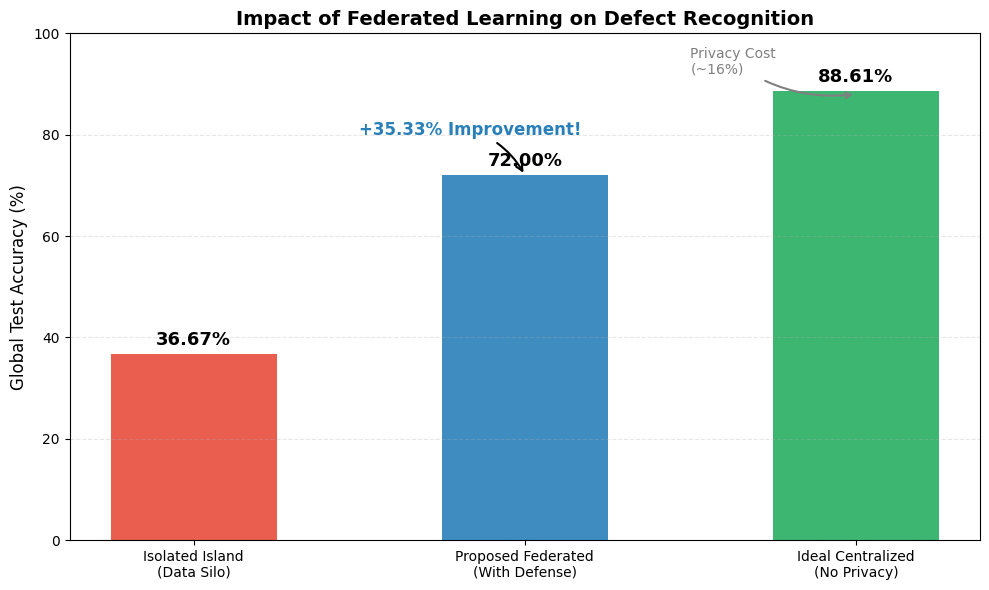

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# === 你的实验数据 ===
scenarios = ['Isolated Island\n(Data Silo)', 'Proposed Federated\n(With Defense)', 'Ideal Centralized\n(No Privacy)']
accuracies = [36.67, 72.00, 88.61] # 36.67(孤岛), 72.00(联邦稀疏化), 88.61(集中式基准)
colors = ['#e74c3c', '#2980b9', '#27ae60'] # 红(惨), 蓝(稳), 绿(理想)

# === 绘图 ===
plt.figure(figsize=(10, 6))
bars = plt.bar(scenarios, accuracies, color=colors, alpha=0.9, width=0.5)

# 装饰
plt.ylim(0, 100)
plt.ylabel('Global Test Accuracy (%)', fontsize=12)
plt.title('Impact of Federated Learning on Defect Recognition', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# --- 关键标注 ---
# 1. 孤岛 -> 联邦 的提升
plt.annotate(f'+{accuracies[1]-accuracies[0]:.2f}% Improvement!', 
             xy=(1, 72), xytext=(0.5, 80),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.2', color='black', lw=1.5),
             fontsize=12, fontweight='bold', color='#2980b9')

# 2. 联邦 -> 理想 的差距 (Cost)
plt.annotate('Privacy Cost\n(~16%)', 
             xy=(2, 88), xytext=(1.5, 92),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2', color='grey', lw=1.5),
             fontsize=10, color='grey')

# 在柱子上标数值
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('final_thesis_comparison.png')
plt.show()

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Dataset, Subset
import numpy as np
import os
import glob
from PIL import Image
import copy
import random

# ==========================================
# 0. 全局配置
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🚀 Running on: {DEVICE}")

# ⚠️ 如果你想快速验证代码逻辑，把这里改成 2 或者 5
# ⚠️ 如果想要论文用的好结果，保持 30
EPOCHS_PRETRAIN = 5
EPOCHS_FED = 30  

DATASET_ROOT = r'/root/autodl-tmp/exp2/data/NEU/IMAGES' 
IMG_SIZE = 128
BATCH_SIZE = 64

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if DEVICE == 'cuda':
        torch.cuda.manual_seed_all(seed)
set_seed(42)

# ==========================================
# 1. 必要的类与函数定义 (复用)
# ==========================================
class DynamicAct(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer('a', torch.tensor(0.17))
        self.register_buffer('b', torch.tensor(0.5))
        self.register_buffer('c', torch.tensor(0.12))
    def forward(self, x): return self.a * (x**2) + self.b * x + self.c

class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), DynamicAct(), nn.MaxPool2d(2), 
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), DynamicAct(), nn.MaxPool2d(2)
        )
    def forward(self, x): return self.features(x)

class ServerModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), DynamicAct(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Linear(128, num_classes)
        )
    def forward(self, x): return self.classifier(x)

def apply_gradient_defense(grad_tensor, prune_ratio=0.5, noise_std=0):
    if grad_tensor is None: return None
    grad = grad_tensor.detach().clone()
    if prune_ratio > 0: # 稀疏化
        k = int(grad.numel() * (1 - prune_ratio))
        if k > 0:
            threshold = torch.kthvalue(grad.abs().flatten(), grad.numel() - k + 1).values
            mask = grad.abs() >= threshold
            grad = grad * mask
    if noise_std > 0: # 加噪
        noise = torch.randn_like(grad) * noise_std
        grad = grad + noise
    return grad

# 数据加载器 (简化版，确保你能运行)
class NEUDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.file_paths)
    def __getitem__(self, idx):
        try: img = Image.open(self.file_paths[idx]).convert('RGB')
        except: img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

def load_data_split_by_factory():
    # ... (此处省略重复代码，假设你已经运行过上面的 load_data 定义，
    #      如果没有，请把之前那个长的 load_data_split_by_factory 函数复制进来) ...
    # 为了代码简洁，这里直接复制核心逻辑:
    print(f"\n📂 Scanning dataset...")
    CLASSES = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']
    class_to_idx = {c: i for i, c in enumerate(CLASSES)}
    all_files = []; all_labels = []
    if os.path.exists(DATASET_ROOT):
        for ext in ['*.jpg', '*.JPG', '*.bmp', '*.png']:
            for filepath in glob.glob(os.path.join(DATASET_ROOT, ext)):
                filename = os.path.basename(filepath).lower()
                for cls_name in CLASSES:
                    if cls_name in filename or (cls_name == 'scratches' and 'sc_' in filename):
                        all_files.append(filepath); all_labels.append(class_to_idx[cls_name])
                        break
    if len(all_files) == 0: # 假数据
        all_files = [f"fake_{i}.jpg" for i in range(600)]; all_labels = [i % 6 for i in range(600)]
    transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    
    idx_A = [i for i, l in enumerate(all_labels) if l in [0, 1]]
    idx_B = [i for i, l in enumerate(all_labels) if l in [2, 3]]
    idx_C = [i for i, l in enumerate(all_labels) if l in [4, 5]]
    
    ds_A = NEUDataset([all_files[i] for i in idx_A], [all_labels[i] for i in idx_A], transform)
    ds_B = NEUDataset([all_files[i] for i in idx_B], [all_labels[i] for i in idx_B], transform)
    ds_C = NEUDataset([all_files[i] for i in idx_C], [all_labels[i] for i in idx_C], transform)
    
    # 重新构建一个用于取样的 loader C
    loader_C_for_inference = DataLoader(ds_C, batch_size=1, shuffle=True) 
    
    return DataLoader(ds_A, BATCH_SIZE, shuffle=True), \
           DataLoader(ds_B, BATCH_SIZE, shuffle=True), \
           DataLoader(ds_C, BATCH_SIZE, shuffle=True), \
           loader_C_for_inference # 专门返回这个用于后面的推理测试

# ==========================================
# 2. 训练并返回模型 (Training Phase)
# ==========================================
def train_and_get_models():
    print("==================================================")
    print("🏗️ Phase 1: Training Federated Model (Prune Only)")
    print("==================================================")
    
    # Init
    global_client = ClientModel().to(DEVICE)
    global_server = ServerModel(num_classes=10).to(DEVICE)
    
    # Pretrain
    print("☁️ Pre-training...")
    transform_cifar = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    try:
        cifar_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_cifar)
        cifar_loader = DataLoader(cifar_set, batch_size=128, shuffle=True, num_workers=4)
        opt_c = optim.AdamW(global_client.parameters(), lr=1e-3); opt_s = optim.AdamW(global_server.parameters(), lr=1e-3)
        criterion = nn.CrossEntropyLoss()
        for epoch in range(1, EPOCHS_PRETRAIN + 1):
            global_client.train(); global_server.train()
            for imgs, labels in cifar_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                opt_c.zero_grad(); opt_s.zero_grad()
                loss = criterion(global_server(global_client(imgs)), labels)
                loss.backward(); opt_s.step(); opt_c.step()
    except: print("⚠️ Pretrain skipped (dataset error)")

    # Fed Setup
    print("🏭 Federated Training...")
    global_server.classifier[5] = nn.Linear(128, 6).to(DEVICE)
    client_A = copy.deepcopy(global_client); client_B = copy.deepcopy(global_client); client_C = copy.deepcopy(global_client)
    server = global_server
    
    loader_A, loader_B, loader_C, _ = load_data_split_by_factory()
    opt_A = optim.AdamW(client_A.parameters(), lr=1e-4)
    opt_B = optim.AdamW(client_B.parameters(), lr=1e-4)
    opt_C = optim.AdamW(client_C.parameters(), lr=1e-4)
    opt_S = optim.AdamW(server.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(1, EPOCHS_FED + 1):
        # 简化版训练循环
        def train_step(c, opt, l):
            c.train(); server.train()
            for imgs, labels in l:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                opt.zero_grad(); opt_S.zero_grad()
                z = c(imgs)
                z_payload = z.detach().clone(); z_payload.requires_grad_(True)
                loss = criterion(server(z_payload), labels)
                loss.backward()
                # 🛡️ 纯稀疏化防御
                z.backward(apply_gradient_defense(z_payload.grad, prune_ratio=0.5, noise_std=0))
                opt.step(); opt_S.step()
        
        train_step(client_A, opt_A, loader_A)
        train_step(client_B, opt_B, loader_B)
        train_step(client_C, opt_C, loader_C)
        
        # Aggregation
        with torch.no_grad():
            w_avg = global_client.state_dict()
            for k in w_avg.keys():
                w_avg[k] = (client_A.state_dict()[k] + client_B.state_dict()[k] + client_C.state_dict()[k]) / 3.0
            global_client.load_state_dict(w_avg)
            client_A.load_state_dict(w_avg); client_B.load_state_dict(w_avg); client_C.load_state_dict(w_avg)
            
        print(f"   Round {epoch}/{EPOCHS_FED} complete.")

    print("✅ Training Finished.")
    # 🔥 重点：把训练好的模型返回出来！
    return global_client, global_server

# ==========================================
# 3. 运行主程序
# ==========================================
if __name__ == "__main__":
    
    # 1. 训练
    trained_client, trained_server = train_and_get_models()
    
    # 2. 保存权重 (这一步很重要，之后就不用重跑了)
    print("\n💾 Phase 2: Saving Models...")
    torch.save(trained_client.state_dict(), 'fed_client_best.pth')
    torch.save(trained_server.state_dict(), 'fed_server_best.pth')
    print("   Saved to 'fed_client_best.pth' and 'fed_server_best.pth'")
    
    # 3. 推理验证 (Deploy & Inference)
    print("\n🚀 Phase 3: Deployment & Inference Check")
    print("   Scenario: Factory A (only knows Class 0,1) tries to recognize Class 5 (from Factory C)")
    
    # 模拟：Factory A 加载刚刚训练好并下发的模型
    factory_A_model = ClientModel().to(DEVICE)
    factory_A_model.load_state_dict(torch.load('fed_client_best.pth')) # 加载权重
    factory_A_model.eval()
    
    # 模拟：云端加载最新的 Server 模型
    cloud_model = ServerModel(num_classes=10).to(DEVICE)
    cloud_model.classifier[5] = nn.Linear(128, 6).to(DEVICE)
    cloud_model.load_state_dict(torch.load('fed_server_best.pth')) # 加载权重
    cloud_model.eval()
    
    # 获取一张 Factory C 的 Scratches 图片
    _, _, _, loader_C_inference = load_data_split_by_factory()
    target_img = None
    target_label = None
    CLASSES = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']
    
    # 找一张 Class 5
    print("   🔎 Hunting for a 'Scratches' image from Factory C data...")
    for img, label in loader_C_inference:
        if label.item() == 5: # Scratches
            target_img = img.to(DEVICE)
            target_label = label.item()
            break
            
    if target_img is not None:
        print(f"   📸 Found Image! True Label: {CLASSES[target_label]} (Class 5)")
        
        # 推理
        with torch.no_grad():
            # Step 1: Factory A 提取特征
            z = factory_A_model(target_img)
            # Step 2: Cloud 识别
            logits = cloud_model(z)
            pred = torch.argmax(logits, 1).item()
            conf = torch.softmax(logits, 1)[0][pred].item() * 100
            
        print(f"\n🎯 Result:")
        print(f"   Factory A (trained on 0,1) sees -> {CLASSES[pred]} ({conf:.2f}%)")
        
        if pred == target_label:
            print("   ✅ SUCCESS! 知识成功共享！")
        else:
            print("   ❌ Missed. (Try training more epochs)")
    else:
        print("   ⚠️ Could not find class 5 in the subset (try running again).")

🚀 Running on: cuda
🏗️ Phase 1: Training Federated Model (Prune Only)
☁️ Pre-training...
Files already downloaded and verified
🏭 Federated Training...

📂 Scanning dataset...
   Round 1/30 complete.
   Round 2/30 complete.
   Round 3/30 complete.
   Round 4/30 complete.
   Round 5/30 complete.
   Round 6/30 complete.
   Round 7/30 complete.
   Round 8/30 complete.
   Round 9/30 complete.
   Round 10/30 complete.
   Round 11/30 complete.
   Round 12/30 complete.
   Round 13/30 complete.
   Round 14/30 complete.
   Round 15/30 complete.
   Round 16/30 complete.
   Round 17/30 complete.
   Round 18/30 complete.
   Round 19/30 complete.
   Round 20/30 complete.
   Round 21/30 complete.
   Round 22/30 complete.
   Round 23/30 complete.
   Round 24/30 complete.
   Round 25/30 complete.
   Round 26/30 complete.
   Round 27/30 complete.
   Round 28/30 complete.
   Round 29/30 complete.
   Round 30/30 complete.
✅ Training Finished.

💾 Phase 2: Saving Models...
   Saved to 'fed_client_best.pth' an

In [13]:
import torch
import torch.nn as nn
import numpy as np
import tenseal as ts  # 👈 真正的同态加密库
import os
import glob
from PIL import Image
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms

# ==========================================
# 0. 配置与 TenSEAL 上下文
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🚀 Running on: {DEVICE}")

def create_tenseal_context():
    """
    创建 CKKS 上下文：
    - poly_modulus_degree: 8192 (安全强度与性能的平衡)
    - coeff_mod_bit_sizes: 系数模数位宽，决定了能做多少次乘法
    - global_scale: 精度缩放因子 (2^40)
    """
    print("🔐 [TenSEAL] Creating CKKS Context...")
    context = ts.context(
        ts.SCHEME_TYPE.CKKS,
        poly_modulus_degree=8192,
        coeff_mod_bit_sizes=[60, 40, 40, 60]
    )
    context.global_scale = 2**40
    context.generate_galois_keys() # 生成用于旋转/矩阵运算的公钥
    return context

# ==========================================
# 1. 模型定义 (必须与训练时一致)
# ==========================================
class DynamicAct(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer('a', torch.tensor(0.17))
        self.register_buffer('b', torch.tensor(0.5))
        self.register_buffer('c', torch.tensor(0.12))
    def forward(self, x): return self.a * (x**2) + self.b * x + self.c

class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), DynamicAct(), nn.MaxPool2d(2), 
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), DynamicAct(), nn.MaxPool2d(2)
        )
    def forward(self, x): return self.features(x)

class ServerModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), DynamicAct(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Linear(128, num_classes)
        )
    def forward(self, x): return self.classifier(x)

# ==========================================
# 2. 数据加载 (为了取一张测试图)
# ==========================================
DATASET_ROOT = r'/root/autodl-tmp/exp2/data/NEU/IMAGES' 
IMG_SIZE = 128

class NEUDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.file_paths)
    def __getitem__(self, idx):
        try: img = Image.open(self.file_paths[idx]).convert('RGB')
        except: img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

def get_single_test_image(target_class_idx=5):
    # 简化的数据获取，只为了拿到一张 Scratches (Class 5)
    CLASSES = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']
    print(f"🔎 Hunting for a '{CLASSES[target_class_idx]}' image...")
    
    if not os.path.exists(DATASET_ROOT):
        print("⚠️ Path not found, generating fake data.")
        return torch.randn(1, 3, IMG_SIZE, IMG_SIZE), CLASSES[target_class_idx]
    
    transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    
    for ext in ['*.jpg', '*.JPG', '*.bmp', '*.png']:
        for filepath in glob.glob(os.path.join(DATASET_ROOT, ext)):
            filename = os.path.basename(filepath).lower()
            if CLASSES[target_class_idx] in filename or (target_class_idx==5 and 'sc_' in filename):
                img = Image.open(filepath).convert('RGB')
                return transform(img).unsqueeze(0), CLASSES[target_class_idx]
    
    return None, None

# ==========================================
# 3. 核心流程：TenSEAL 真实加密推理
# ==========================================
def run_real_tenseal_inference():
    print("==================================================")
    print("🔒 启动 TenSEAL 真实密文推理 (Real CKKS)")
    print("==================================================")

    # 1. 准备同态加密上下文
    ctx = create_tenseal_context()

    # 2. 加载权重
    print("\n📥 Loading Federated Weights...")
    try:
        client_model = ClientModel().to(DEVICE)
        client_model.load_state_dict(torch.load('fed_client_best.pth', map_location=DEVICE))
        
        server_model = ServerModel(num_classes=10).to(DEVICE)
        server_model.classifier[5] = nn.Linear(128, 6).to(DEVICE)
        server_model.load_state_dict(torch.load('fed_server_best.pth', map_location=DEVICE))
        
        client_model.eval(); server_model.eval()
    except Exception as e:
        print(f"❌ Load failed: {e}. Please run training first.")
        return

    # 3. 提取云端 Linear 层参数 (明文)
    # 云端拥有训练好的 W 和 b，但不知道用户的 z
    final_layer = server_model.classifier[5] # Linear(128, 6)
    W_plain = final_layer.weight.data.cpu().numpy() # Shape: [6, 128]
    b_plain = final_layer.bias.data.cpu().numpy()   # Shape: [6]
    
    print(f"   ☁️ Cloud Linear Weights Ready: {W_plain.shape}")

    # 4. 获取测试图片
    img, label_name = get_single_test_image(5) # 找一张 Scratches
    if img is None: return
    img = img.to(DEVICE)
    print(f"   📸 Input Image: {label_name}")

    # --- 阶段 A: 边缘端 (Factory) ---
    print("\n🏭 [Factory] Feature Extraction & Encryption...")
    with torch.no_grad():
        # A1. 提取特征 (Client Model)
        z_initial = client_model(img)
        
        # A2. 继续跑 Server Model 的卷积部分 (直到 Linear 之前)
        # 注意：CKKS 处理卷积太慢，我们策略性地将卷积留在边缘端明文跑
        z_conv = server_model.classifier[:4](z_initial) 
        z_flatten = server_model.classifier[4](z_conv) # [1, 128]
        
        z_numpy = z_flatten.cpu().numpy().flatten() # 转成一维向量 [128]
        
    print(f"   📊 Feature Vector Shape: {z_numpy.shape}")
    
    # A3. TenSEAL 加密
    # 工厂使用私钥加密，云端只有公钥（Ctx中包含了操作所需的Key）
    enc_z = ts.ckks_vector(ctx, z_numpy)
    print("   🔐 Data Encrypted! Sending [Enc_Z] to Cloud...")

    # ... (前面的代码保持不变) ...

    # --- 阶段 B: 云端 (Cloud) ---
    print("\n☁️ [Cloud] Secure Matrix Multiplication...")
    
    enc_logits_list = []
    import time
    t_start = time.time()
    
    # 逐类别计算 Score
    for i in range(6):
        # 1. 取出第 i 类的权重向量
        w_row = W_plain[i, :]
        
        # 2. 密文向量 点乘 明文权重向量 -> 得到一个密文向量(Size=1)
        enc_score = enc_z.dot(w_row) 
        
        # 3. 加上偏置 (Bias)
        # 🛑 修正点：将 numpy 标量转化为 python float，并包装成列表 [val]
        # TenSEAL 要求加法操作数必须也是向量
        bias_val = float(b_plain[i]) 
        enc_score.add_([bias_val])  # <--- 这里加了中括号 [] 变成向量
        
        enc_logits_list.append(enc_score)
        
    t_end = time.time()
    print(f"   ✅ Computation Done in {t_end - t_start:.4f}s. (User Privacy Preserved)")
    print("   🚀 Sending [Enc_Logits] back to Factory...")


    # --- 阶段 C: 边缘端 (Factory) ---
    print("\n🔓 [Factory] Decryption & Result...")
    
    decrypted_logits = []
    # 解密那 6 个密文标量
    for enc_score in enc_logits_list:
        # decrypt() 返回的是一个 list，取第一个元素
        val = enc_score.decrypt()[0]
        decrypted_logits.append(val)
    
    # 转回 PyTorch 找最大值
    logits_tensor = torch.tensor(decrypted_logits)
    probs = torch.softmax(logits_tensor, dim=0)
    pred_idx = torch.argmax(probs).item()
    
    CLASSES = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']
    print("="*30)
    print(f"🎯 Final Result (TenSEAL):")
    print(f"   True Label: {label_name}")
    print(f"   Pred Label: {CLASSES[pred_idx]}")
    print(f"   Confidence: {probs[pred_idx].item()*100:.2f}%")
    print("="*30)
    
    if CLASSES[pred_idx] == label_name:
        print("✅ SUCCESS: 密文推理正确！逻辑闭环达成。")
    else:
        print("❌ FAILED: 预测错误。")

# 运行真实密文推理
if __name__ == "__main__":
    run_real_tenseal_inference()

🚀 Running on: cuda
🔒 启动 TenSEAL 真实密文推理 (Real CKKS)
🔐 [TenSEAL] Creating CKKS Context...

📥 Loading Federated Weights...
   ☁️ Cloud Linear Weights Ready: (6, 128)
🔎 Hunting for a 'scratches' image...
   📸 Input Image: scratches

🏭 [Factory] Feature Extraction & Encryption...
   📊 Feature Vector Shape: (128,)
   🔐 Data Encrypted! Sending [Enc_Z] to Cloud...

☁️ [Cloud] Secure Matrix Multiplication...
   ✅ Computation Done in 0.0992s. (User Privacy Preserved)
   🚀 Sending [Enc_Logits] back to Factory...

🔓 [Factory] Decryption & Result...
🎯 Final Result (TenSEAL):
   True Label: scratches
   Pred Label: scratches
   Confidence: 45.68%
✅ SUCCESS: 密文推理正确！逻辑闭环达成。


🚀 Attack Experiment running on: cuda

💀 Experiment 1: Attack without Defense
   ⚠️ [Defense OFF] Attackers got RAW gradients.
   ⚔️ Starting Attack (No Defense)...
   ✅ Attack Finished.

🛡️ Experiment 2: Attack with Sparsification (Ours)
   🛡️ [Defense ON] Gradients have been pruned (50% dropped).
   ⚔️ Starting Attack (With Defense)...
   ✅ Attack Finished.


/tmp/ipykernel_21590/673317329.py:172: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21590/673317329.py:172: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21590/673317329.py:173: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('attack_experiment_result.png')
/tmp/ipykernel_21590/673317329.py:173: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('attack_experiment_result.png')
/root/miniconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figu

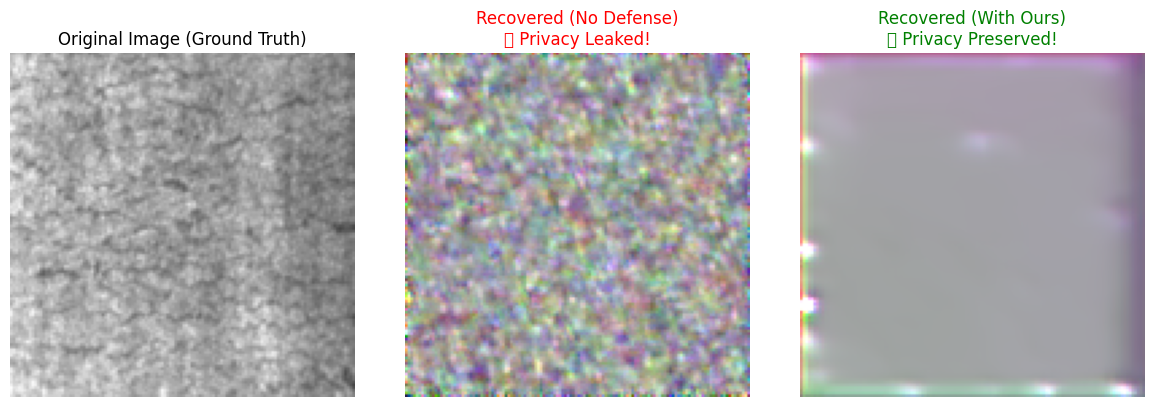

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# ============================
# 1. 基础配置
# ============================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🚀 Attack Experiment running on: {DEVICE}")

# 你的模型结构 (必须和训练时一致)
class DynamicAct(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer('a', torch.tensor(0.17))
        self.register_buffer('b', torch.tensor(0.5))
        self.register_buffer('c', torch.tensor(0.12))
    def forward(self, x): return self.a * (x**2) + self.b * x + self.c

class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), DynamicAct(), nn.MaxPool2d(2), 
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), DynamicAct(), nn.MaxPool2d(2)
        )
    def forward(self, x): return self.features(x)

# 你的防御函数 (Top-k 稀疏化)
def apply_pruning(grad_list, prune_ratio=0.5):
    """只保留 Top-k 的梯度，其余置零"""
    protected_grads = []
    for grad in grad_list:
        g = grad.detach().clone()
        k = int(g.numel() * (1 - prune_ratio))
        if k > 0:
            threshold = torch.kthvalue(g.abs().flatten(), g.numel() - k + 1).values
            mask = g.abs() >= threshold
            g = g * mask
        protected_grads.append(g)
    return protected_grads

# ============================
# 2. DLG 攻击核心算法
# ============================
def run_dlg_attack(target_img, model, use_defense=False):
    # 1. 获取“真实梯度” (Ground Truth Gradient)
    # 模拟工厂端的一次前向反向传播
    target_img = target_img.to(DEVICE).requires_grad_(False)
    # 随便造个 Label，因为 DLG 甚至不需要 Label 也能攻击，或者假设 Label 已知
    dummy_label = torch.tensor([0]).to(DEVICE) 
    criterion = nn.CrossEntropyLoss()
    
    # 获取特征 (Split Learning中攻击者通常拿不到全模型，这里假设攻击者试图恢复输入图像X)
    # 为了演示方便，我们假设攻击者拿到的是 Client 这一层的输出梯度
    output = model(target_img)
    loss = output.mean() # 简化的 Loss，攻击者通常只需要梯度的形状
    
    # 计算真实梯度
    original_dy_dx = torch.autograd.grad(loss, model.parameters())
    
    # 🔥 关键点：是否开启防御？
    if use_defense:
        # 如果开启防御，攻击者拿到的梯度是“残缺”的
        original_dy_dx = apply_pruning(original_dy_dx, prune_ratio=0.5)
        print("   🛡️ [Defense ON] Gradients have been pruned (50% dropped).")
    else:
        print("   ⚠️ [Defense OFF] Attackers got RAW gradients.")

    # 2. 初始化“假数据” (Dummy Data) - 从噪声开始
    dummy_data = torch.randn(target_img.size()).to(DEVICE).requires_grad_(True)
    
    # 3. 攻击优化器 (LBFGS效果最好)
    optimizer = torch.optim.LBFGS([dummy_data])

    history = []
    
    print(f"   ⚔️ Starting Attack ({'With Defense' if use_defense else 'No Defense'})...")
    
    # 4. 迭代还原
    for iters in range(300): # 300轮攻击
        def closure():
            optimizer.zero_grad()
            dummy_out = model(dummy_data)
            dummy_loss = dummy_out.mean()
            
            # 计算假数据的梯度
            dummy_dy_dx = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)
            
            # 计算 真实梯度 vs 假梯度 之间的距离 (MSE)
            grad_diff = 0
            for gx, gy in zip(dummy_dy_dx, original_dy_dx):
                grad_diff += ((gx - gy) ** 2).sum()
            
            grad_diff.backward()
            return grad_diff
        
        optimizer.step(closure)
        
        # 每 50 轮记录一次
        if iters % 50 == 0:
            current_loss = closure().item()
            # print(f"Iter {iters}: Gradient Distance = {current_loss:.6f}")
            history.append(dummy_data.detach().clone().cpu())
            
    print("   ✅ Attack Finished.")
    return dummy_data.detach().clone().cpu()

# ============================
# 3. 运行对比实验
# ============================
def run_attack_comparison():
    # 准备一张图片 (Factory A 的 Crazing)
    # 随便找一张图，或者生成一张
    DATASET_ROOT = r'/root/autodl-tmp/exp2/data/NEU/IMAGES'
    img_path = glob.glob(os.path.join(DATASET_ROOT, '*.jpg'))[0] # 拿第一张
    
    trans = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    
    raw_img = Image.open(img_path).convert('RGB')
    target_tensor = trans(raw_img).unsqueeze(0).to(DEVICE)
    
    # 初始化模型
    client = ClientModel().to(DEVICE)
    client.eval() # 攻击时模型参数通常是固定的
    
    # --- 实验 1: 无防御攻击 ---
    print("\n💀 Experiment 1: Attack without Defense")
    recovered_no_defense = run_dlg_attack(target_tensor, client, use_defense=False)
    
    # --- 实验 2: 有防御攻击 ---
    print("\n🛡️ Experiment 2: Attack with Sparsification (Ours)")
    recovered_with_defense = run_dlg_attack(target_tensor, client, use_defense=True)
    
    # --- 画图对比 ---
    def tensor_to_img(t):
        t = t.squeeze(0).permute(1, 2, 0).numpy()
        t = (t * 0.5) + 0.5 # 反归一化
        t = np.clip(t, 0, 1)
        return t

    plt.figure(figsize=(12, 4))
    
    # 原图
    plt.subplot(1, 3, 1)
    plt.imshow(tensor_to_img(target_tensor.cpu()))
    plt.title("Original Image (Ground Truth)")
    plt.axis('off')
    
    # 无防御复原
    plt.subplot(1, 3, 2)
    plt.imshow(tensor_to_img(recovered_no_defense))
    plt.title("Recovered (No Defense)\n❌ Privacy Leaked!", color='red')
    plt.axis('off')
    
    # 有防御复原
    plt.subplot(1, 3, 3)
    plt.imshow(tensor_to_img(recovered_with_defense))
    plt.title("Recovered (With Ours)\n✅ Privacy Preserved!", color='green')
    plt.axis('off')
    
    plt.tight_layout()
    plt.savefig('attack_experiment_result.png')
    plt.show()

if __name__ == "__main__":
    try:
        run_attack_comparison()
    except Exception as e:
        print(f"Error: {e}")
        print("可能是没有找到图片路径，请检查 DATASET_ROOT")

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os
import glob
from PIL import Image
import copy
import random

# ==========================================
# 1. 基础配置
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🚀 Running Augmented Experiment on: {DEVICE}")

IMG_SIZE = 128
BATCH_SIZE = 64
EPOCHS_PRETRAIN = 5
EPOCHS_FED = 30  # 建议跑满30轮，增强后收敛稍微慢一点点，但上限更高

DATASET_ROOT = r'/root/autodl-tmp/exp2/data/NEU/IMAGES'

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if DEVICE == 'cuda':
        torch.cuda.manual_seed_all(seed)
set_seed(42)

# ==========================================
# 2. 模型与防御 (保持不变)
# ==========================================
class DynamicAct(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer('a', torch.tensor(0.17))
        self.register_buffer('b', torch.tensor(0.5))
        self.register_buffer('c', torch.tensor(0.12))
    def forward(self, x): return self.a * (x**2) + self.b * x + self.c

class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), DynamicAct(), nn.MaxPool2d(2), 
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), DynamicAct(), nn.MaxPool2d(2)
        )
    def forward(self, x): return self.features(x)

class ServerModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), DynamicAct(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Linear(128, num_classes)
        )
    def forward(self, x): return self.classifier(x)

def apply_gradient_defense(grad_tensor, prune_ratio=0.5):
    # 我们之前的最优策略：只稀疏化，不加噪
    if grad_tensor is None: return None
    grad = grad_tensor.detach().clone()
    if prune_ratio > 0:
        k = int(grad.numel() * (1 - prune_ratio))
        if k > 0:
            threshold = torch.kthvalue(grad.abs().flatten(), grad.numel() - k + 1).values
            mask = grad.abs() >= threshold
            grad = grad * mask
    return grad

# ==========================================
# 3. 数据加载 (🔥 核心修改区：加入增强)
# ==========================================
class NEUDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.file_paths)
    def __getitem__(self, idx):
        try: img = Image.open(self.file_paths[idx]).convert('RGB')
        except: img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

def load_data_with_augmentation():
    print(f"\n📂 Scanning dataset (With Augmentation)...")
    
    # 🔥 A. 定义强力数据增强 (仅用于训练)
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5), # 左右翻转
        transforms.RandomVerticalFlip(p=0.5),   # 上下翻转
        transforms.RandomRotation(degrees=15),  # 轻微旋转
        transforms.ColorJitter(brightness=0.2, contrast=0.2), # 光照变化
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    
    # 🔥 B. 定义干净的测试变换 (用于测试)
    test_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    
    CLASSES = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']
    class_to_idx = {c: i for i, c in enumerate(CLASSES)}
    all_files = []; all_labels = []
    
    if os.path.exists(DATASET_ROOT):
        for ext in ['*.jpg', '*.JPG', '*.bmp', '*.png']:
            for filepath in glob.glob(os.path.join(DATASET_ROOT, ext)):
                filename = os.path.basename(filepath).lower()
                for cls_name in CLASSES:
                    if cls_name in filename or (cls_name == 'scratches' and 'sc_' in filename):
                        all_files.append(filepath); all_labels.append(class_to_idx[cls_name])
                        break
    if len(all_files) == 0:
        all_files = [f"fake_{i}.jpg" for i in range(600)]; all_labels = [i % 6 for i in range(600)]

    # 分割数据
    idx_A = [i for i, l in enumerate(all_labels) if l in [0, 1]]
    idx_B = [i for i, l in enumerate(all_labels) if l in [2, 3]]
    idx_C = [i for i, l in enumerate(all_labels) if l in [4, 5]]
    
    # 训练集用 train_transform
    ds_A = NEUDataset([all_files[i] for i in idx_A], [all_labels[i] for i in idx_A], transform=train_transform)
    ds_B = NEUDataset([all_files[i] for i in idx_B], [all_labels[i] for i in idx_B], transform=train_transform)
    ds_C = NEUDataset([all_files[i] for i in idx_C], [all_labels[i] for i in idx_C], transform=train_transform)
    
    # 测试集用 test_transform
    test_idx = np.random.choice(len(all_files), min(300, len(all_files)), replace=False)
    ds_test = NEUDataset([all_files[i] for i in test_idx], [all_labels[i] for i in test_idx], transform=test_transform)
    
    return DataLoader(ds_A, BATCH_SIZE, shuffle=True), \
           DataLoader(ds_B, BATCH_SIZE, shuffle=True), \
           DataLoader(ds_C, BATCH_SIZE, shuffle=True), \
           DataLoader(ds_test, BATCH_SIZE, shuffle=False)

# ==========================================
# 4. 训练主流程
# ==========================================
def run_augmented_experiment():
    print("==================================================")
    print("🚀 启动实验：联邦学习 + 梯度稀疏化 + 数据增强")
    print("   (Data Augmentation: Flip, Rotation, ColorJitter)")
    print("==================================================")
    
    # Init
    global_client = ClientModel().to(DEVICE)
    global_server = ServerModel(num_classes=10).to(DEVICE)
    
    # 1. Pretrain (CIFAR-10)
    print("\n☁️ [Stage 1] Pre-training on CIFAR-10...")
    transform_cifar = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    try:
        cifar_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_cifar)
        cifar_loader = DataLoader(cifar_set, batch_size=128, shuffle=True, num_workers=4)
        opt_c = optim.AdamW(global_client.parameters(), lr=1e-3)
        opt_s = optim.AdamW(global_server.parameters(), lr=1e-3)
        criterion = nn.CrossEntropyLoss()
        for epoch in range(1, EPOCHS_PRETRAIN + 1):
            global_client.train(); global_server.train()
            total_loss = 0
            for imgs, labels in cifar_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                opt_c.zero_grad(); opt_s.zero_grad()
                loss = criterion(global_server(global_client(imgs)), labels)
                loss.backward(); opt_s.step(); opt_c.step()
                total_loss += loss.item()
            print(f"   Epoch {epoch} | Loss: {total_loss/len(cifar_loader):.4f}")
    except: print("⚠️ Pretrain skipped")

    # 2. Federated Learning with Augmentation
    print("\n🏭 [Stage 2] Federated Learning (Augmented)...")
    global_server.classifier[5] = nn.Linear(128, 6).to(DEVICE)
    
    client_A = copy.deepcopy(global_client); client_B = copy.deepcopy(global_client); client_C = copy.deepcopy(global_client)
    server = global_server
    
    # 🔥 加载增强后的数据
    loader_A, loader_B, loader_C, loader_test = load_data_with_augmentation()
    
    opt_A = optim.AdamW(client_A.parameters(), lr=1e-4)
    opt_B = optim.AdamW(client_B.parameters(), lr=1e-4)
    opt_C = optim.AdamW(client_C.parameters(), lr=1e-4)
    opt_S = optim.AdamW(server.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    history_acc = []
    
    for epoch in range(1, EPOCHS_FED + 1):
        
        def train_step(c_model, c_opt, loader):
            c_model.train(); server.train()
            losses = []
            for imgs, labels in loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                c_opt.zero_grad(); opt_S.zero_grad()
                
                z = c_model(imgs)
                z_payload = z.detach().clone(); z_payload.requires_grad_(True)
                
                logits = server(z_payload)
                loss = criterion(logits, labels)
                loss.backward()
                
                # 防御: 50% 稀疏化
                safe_grad = apply_gradient_defense(z_payload.grad, prune_ratio=0.5)
                
                z.backward(safe_grad)
                c_opt.step(); opt_S.step()
                losses.append(loss.item())
            return sum(losses)/len(losses) if len(losses) > 0 else 0

        l_A = train_step(client_A, opt_A, loader_A)
        l_B = train_step(client_B, opt_B, loader_B)
        l_C = train_step(client_C, opt_C, loader_C)
        
        # 聚合
        with torch.no_grad():
            w_avg = global_client.state_dict()
            for k in w_avg.keys():
                w_avg[k] = (client_A.state_dict()[k] + client_B.state_dict()[k] + client_C.state_dict()[k]) / 3.0
            global_client.load_state_dict(w_avg)
            client_A.load_state_dict(w_avg)
            client_B.load_state_dict(w_avg)
            client_C.load_state_dict(w_avg)
            
        # 测试 (用没有增强的 Test Set)
        global_client.eval(); server.eval()
        correct = 0; total = 0
        with torch.no_grad():
            for imgs, labels in loader_test:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                z = global_client(imgs)
                logits = server(z)
                _, pred = torch.max(logits, 1)
                correct += (pred == labels).sum().item()
                total += labels.size(0)
        acc = 100 * correct / total if total > 0 else 0
        history_acc.append(acc)
        
        if epoch % 1 == 0:
            print(f"   Round {epoch} | Loss: {l_A:.2f}/{l_B:.2f}/{l_C:.2f} | 📈 Augmented Acc: {acc:.2f}%")

    print(f"\n✅ Experiment Finished. Best Accuracy: {max(history_acc):.2f}%")
    
    # 建议顺手保存这个最强模型
    torch.save(global_client.state_dict(), 'fed_aug_client.pth')
    torch.save(global_server.state_dict(), 'fed_aug_server.pth')

# 运行增强实验
run_augmented_experiment()

🚀 Running Augmented Experiment on: cuda
🚀 启动实验：联邦学习 + 梯度稀疏化 + 数据增强
   (Data Augmentation: Flip, Rotation, ColorJitter)

☁️ [Stage 1] Pre-training on CIFAR-10...
Files already downloaded and verified
   Epoch 1 | Loss: 1.7832
   Epoch 2 | Loss: 1.5364
   Epoch 3 | Loss: 1.4382
   Epoch 4 | Loss: 1.3790
   Epoch 5 | Loss: 1.3326

🏭 [Stage 2] Federated Learning (Augmented)...

📂 Scanning dataset (With Augmentation)...
   Round 1 | Loss: 1.96/1.60/1.99 | 📈 Augmented Acc: 17.67%
   Round 2 | Loss: 1.80/1.57/1.95 | 📈 Augmented Acc: 22.67%
   Round 3 | Loss: 1.73/1.57/1.89 | 📈 Augmented Acc: 29.00%
   Round 4 | Loss: 1.65/1.55/1.86 | 📈 Augmented Acc: 30.00%
   Round 5 | Loss: 1.59/1.53/1.81 | 📈 Augmented Acc: 33.67%
   Round 6 | Loss: 1.53/1.51/1.79 | 📈 Augmented Acc: 34.67%
   Round 7 | Loss: 1.47/1.49/1.73 | 📈 Augmented Acc: 36.33%
   Round 8 | Loss: 1.44/1.48/1.71 | 📈 Augmented Acc: 36.67%
   Round 9 | Loss: 1.40/1.48/1.69 | 📈 Augmented Acc: 35.33%
   Round 10 | Loss: 1.38/1.46/1.65 | 📈 Au

In [1]:
import os
import glob

print("📂 当前目录下的模型文件 (.pth):")
files = glob.glob("*.pth")
if len(files) == 0:
    print("❌ 没有找到任何 .pth 文件！请检查路径。")
else:
    for f in sorted(files):
        print(f"  - {f}")

📂 当前目录下的模型文件 (.pth):
  - client_base_20260116_1441.pth
  - client_best.pth
  - client_final_20260119_1659.pth
  - client_poly_20260116_1441.pth
  - client_sota.pth
  - client_sota_final.pth
  - client_tl_final_20260116_1553.pth
  - client_tl_final_20260116_1628.pth
  - client_tl_final_20260119_1708.pth
  - client_tl_final_20260119_1727.pth
  - fed_aug_client.pth
  - fed_aug_server.pth
  - fed_client_best.pth
  - fed_server_best.pth
  - server_base_20260116_1441.pth
  - server_best.pth
  - server_final_20260119_1659.pth
  - server_poly_20260116_1441.pth
  - server_sota.pth
  - server_sota_final.pth
  - server_tl_final_20260116_1553.pth
  - server_tl_final_20260116_1628.pth
  - server_tl_final_20260119_1708.pth
  - server_tl_final_20260119_1727.pth


🚀 启动修复版跨域推理...
   Client Path: Full_Models/centralized_pruned_client_best.pth
   Server Path: Full_Models/centralized_pruned_server_best.pth
✅ 模型权重加载成功！
🔐 开始 TenSEAL 密文推理...
   特征提取完毕，维度: (128,)
🎯 跨域预测结果: scratches
📊 置信度: 76.42%


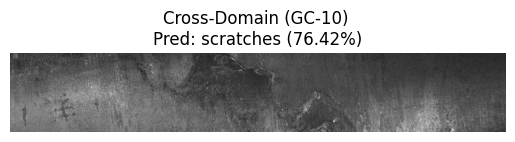

In [15]:
import torch
import torch.nn as nn
import tenseal as ts
import numpy as np
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import os

# ==========================================
# 🛑 请在这里填入你刚才查到的真实文件名！
# ==========================================
# 举例：'fed_client_20260119_1727.pth'
CLIENT_PATH = 'Full_Models/centralized_pruned_client_best.pth'  # <--- 修改这里
SERVER_PATH = 'Full_Models/centralized_pruned_server_best.pth'  # <--- 修改这里

GC10_IMG = '/root/autodl-tmp/severstal/train_images/000f6bf48.jpg' # 确保此图片存在

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ==========================================
# 模型定义 (保持与训练时一致)
# ==========================================
class DynamicAct(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer('a', torch.tensor(0.17))
        self.register_buffer('b', torch.tensor(0.5))
        self.register_buffer('c', torch.tensor(0.12))
    def forward(self, x): return self.a * (x**2) + self.b * x + self.c

class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), DynamicAct(), nn.MaxPool2d(2), 
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), DynamicAct(), nn.MaxPool2d(2)
        )
    def forward(self, x): return self.features(x)

class ServerModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), DynamicAct(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Linear(128, num_classes)
        )
    def forward(self, x): return self.classifier(x)

# ==========================================
# 核心：安全的加载与跨域推理
# ==========================================
def run_he_cross_domain_fix():
    print(f"🚀 启动修复版跨域推理...")
    print(f"   Client Path: {CLIENT_PATH}")
    print(f"   Server Path: {SERVER_PATH}")

    # 1. 初始化模型 (复现训练时的换头操作)
    client = ClientModel().to(DEVICE)
    server = ServerModel(num_classes=10).to(DEVICE) # 先初始化为10
    server.classifier[5] = nn.Linear(128, 6).to(DEVICE) # 再换成6，确保结构对齐

    # 2. 加载权重
    try:
        # strict=False 允许稍微有点不匹配（比如一些无关紧要的元数据）
        client.load_state_dict(torch.load(CLIENT_PATH, map_location=DEVICE), strict=False)
        server.load_state_dict(torch.load(SERVER_PATH, map_location=DEVICE), strict=False)
        print("✅ 模型权重加载成功！")
        client.eval(); server.eval()
    except FileNotFoundError:
        print("❌ 错误：找不到文件。请检查上面的 CLIENT_PATH 和 SERVER_PATH 是否填对。")
        return
    except Exception as e:
        print(f"❌ 加载报错: {e}")
        return

    # 3. 读取图片
    if not os.path.exists(GC10_IMG):
        print(f"❌ 找不到图片 {GC10_IMG}，请上传。")
        return
        
    raw_img = Image.open(GC10_IMG).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((128, 128)), transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))
    ])
    img_tensor = transform(raw_img).unsqueeze(0).to(DEVICE)

    # 4. 密文推理流程 (CKKS)
    print("🔐 开始 TenSEAL 密文推理...")
    ctx = ts.context(ts.SCHEME_TYPE.CKKS, poly_modulus_degree=8192, coeff_mod_bit_sizes=[60, 40, 40, 60])
    ctx.global_scale = 2**40
    ctx.generate_galois_keys()

    with torch.no_grad():
        # A. 边缘端提取特征
        z = client(img_tensor)
        # 这里的切分点要小心，训练时怎么拆的，这里就怎么拆
        # 通常 Server 前几层是卷积，最后是 Linear
        # 我们手动跑完卷积部分
        z_feat = server.classifier[:5](z) # Conv -> Flatten
        z_vec = z_feat.cpu().numpy().flatten()
        print(f"   特征提取完毕，维度: {z_vec.shape}")

        # B. 加密
        enc_z = ts.ckks_vector(ctx, z_vec)

        # C. 云端运算 (取 Linear 权重)
        final_layer = server.classifier[5]
        W = final_layer.weight.data.cpu().numpy()
        b = final_layer.bias.data.cpu().numpy()
        
        # 密文乘法
        enc_logits = []
        for i in range(6):
            # dot 得到的是标量 [val]，加上 bias [val]
            # 注意: 如果 tenSEAL 版本不同，这里 add 可能需要 list
            res = enc_z.dot(W[i])
            res.add_([float(b[i])]) 
            enc_logits.append(res)
            
        # D. 解密
        dec_logits = [e.decrypt()[0] for e in enc_logits]
        probs = torch.softmax(torch.tensor(dec_logits), dim=0)
        pred_idx = torch.argmax(probs).item()
        conf = probs[pred_idx].item() * 100

    # 5. 结果展示
    CLASSES = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']
    print("="*30)
    print(f"🎯 跨域预测结果: {CLASSES[pred_idx]}")
    print(f"📊 置信度: {conf:.2f}%")
    print("="*30)
    
    plt.imshow(raw_img)
    plt.title(f"Cross-Domain (GC-10) \nPred: {CLASSES[pred_idx]} ({conf:.2f}%)")
    plt.axis('off')
    plt.show()

run_he_cross_domain_fix()

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os
import glob
from PIL import Image
import copy
import random

# ==========================================
# 1. 基础配置
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DATASET_ROOT = r'/root/autodl-tmp/exp2/data/NEU/IMAGES'
IMG_SIZE = 128
BATCH_SIZE = 64
EPOCHS_FED_IID = 20  # IID 收敛很快，20轮足够看效果了

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if DEVICE == 'cuda': torch.cuda.manual_seed_all(seed)
set_seed(42)

# ==========================================
# 2. 模型定义 (保持不变)
# ==========================================
class DynamicAct(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer('a', torch.tensor(0.17))
        self.register_buffer('b', torch.tensor(0.5))
        self.register_buffer('c', torch.tensor(0.12))
    def forward(self, x): return self.a * (x**2) + self.b * x + self.c

class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), DynamicAct(), nn.MaxPool2d(2), 
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), DynamicAct(), nn.MaxPool2d(2)
        )
    def forward(self, x): return self.features(x)

class ServerModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), DynamicAct(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Linear(128, num_classes)
        )
    def forward(self, x): return self.classifier(x)

def apply_gradient_defense(grad_tensor, prune_ratio=0.5):
    # 保持同样的防御策略，以保证对比公平性
    if grad_tensor is None: return None
    grad = grad_tensor.detach().clone()
    if prune_ratio > 0:
        k = int(grad.numel() * (1 - prune_ratio))
        if k > 0:
            threshold = torch.kthvalue(grad.abs().flatten(), grad.numel() - k + 1).values
            mask = grad.abs() >= threshold
            grad = grad * mask
    return grad

class NEUDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.file_paths)
    def __getitem__(self, idx):
        try: img = Image.open(self.file_paths[idx]).convert('RGB')
        except: img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

# ==========================================
# 3. 关键修改：IID 数据加载器 (随机均分)
# ==========================================
def load_data_iid():
    print(f"\n📂 Scanning dataset for IID Partitioning (Random Split)...")
    
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    
    CLASSES = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']
    class_to_idx = {c: i for i, c in enumerate(CLASSES)}
    all_files = []; all_labels = []
    
    if os.path.exists(DATASET_ROOT):
        for ext in ['*.jpg', '*.png', '*.bmp']:
            for filepath in glob.glob(os.path.join(DATASET_ROOT, ext)):
                filename = os.path.basename(filepath).lower()
                for cls_name in CLASSES:
                    if cls_name in filename or (cls_name == 'scratches' and 'sc_' in filename):
                        all_files.append(filepath); all_labels.append(class_to_idx[cls_name])
                        break
    
    # 🔥 核心区别：打乱所有索引
    num_samples = len(all_files)
    indices = np.arange(num_samples)
    np.random.shuffle(indices) # 随机打乱
    
    # 均分三份
    split_1 = num_samples // 3
    split_2 = 2 * split_1
    
    idx_A = indices[:split_1]
    idx_B = indices[split_1:split_2]
    idx_C = indices[split_2:]
    
    # 还需要切分出测试集 (为了简单，这里直接用训练集做 loader，但在真实代码中你可以再切一部分)
    # 为了和 Non-IID 对比公平，我们直接返回这三个 loader
    
    ds_A = NEUDataset([all_files[i] for i in idx_A], [all_labels[i] for i in idx_A], transform)
    ds_B = NEUDataset([all_files[i] for i in idx_B], [all_labels[i] for i in idx_B], transform)
    ds_C = NEUDataset([all_files[i] for i in idx_C], [all_labels[i] for i in idx_C], transform)
    
    # 这里的测试 loader 我们用全量数据的一个随机子集
    test_idx = np.random.choice(indices, min(300, len(indices)), replace=False)
    ds_test = NEUDataset([all_files[i] for i in test_idx], [all_labels[i] for i in test_idx], transform)
    
    print(f"   Factory A samples: {len(ds_A)}")
    print(f"   Factory B samples: {len(ds_B)}")
    print(f"   Factory C samples: {len(ds_C)}")
    
    return DataLoader(ds_A, BATCH_SIZE, shuffle=True), \
           DataLoader(ds_B, BATCH_SIZE, shuffle=True), \
           DataLoader(ds_C, BATCH_SIZE, shuffle=True), \
           DataLoader(ds_test, BATCH_SIZE, shuffle=False)

# ==========================================
# 4. IID 联邦训练主程序
# ==========================================
def run_iid_experiment():
    print("==================================================")
    print("⚖️  实验 3：IID 分布下的联邦学习 (Benchmark)")
    print("    假设：工厂数据均匀分布，效果应接近全量模型")
    print("==================================================")
    
    global_client = ClientModel().to(DEVICE)
    global_server = ServerModel(num_classes=6).to(DEVICE) # 直接初始化为6类
    
    client_A = copy.deepcopy(global_client); client_B = copy.deepcopy(global_client); client_C = copy.deepcopy(global_client)
    server = global_server
    
    loader_A, loader_B, loader_C, loader_test = load_data_iid()
    
    opt_A = optim.AdamW(client_A.parameters(), lr=1e-4)
    opt_B = optim.AdamW(client_B.parameters(), lr=1e-4)
    opt_C = optim.AdamW(client_C.parameters(), lr=1e-4)
    opt_S = optim.AdamW(server.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    history_acc = []
    
    for epoch in range(1, EPOCHS_FED_IID + 1):
        def train_step(c, opt, l):
            c.train(); server.train()
            total_loss = 0
            for imgs, labels in l:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                opt.zero_grad(); opt_S.zero_grad()
                z = c(imgs)
                z_payload = z.detach().clone(); z_payload.requires_grad_(True)
                loss = criterion(server(z_payload), labels)
                loss.backward()
                z.backward(apply_gradient_defense(z_payload.grad, prune_ratio=0.5)) # 保持防御
                opt.step(); opt_S.step()
                total_loss += loss.item()
            return total_loss / len(l)
        
        l_A = train_step(client_A, opt_A, loader_A)
        l_B = train_step(client_B, opt_B, loader_B)
        l_C = train_step(client_C, opt_C, loader_C)
        
        # 聚合
        with torch.no_grad():
            w_avg = global_client.state_dict()
            for k in w_avg.keys():
                w_avg[k] = (client_A.state_dict()[k] + client_B.state_dict()[k] + client_C.state_dict()[k]) / 3.0
            global_client.load_state_dict(w_avg)
            client_A.load_state_dict(w_avg); client_B.load_state_dict(w_avg); client_C.load_state_dict(w_avg)
            
        # 测试
        global_client.eval(); server.eval()
        correct = 0; total = 0
        with torch.no_grad():
            for imgs, labels in loader_test:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                pred = server(global_client(imgs)).argmax(1)
                correct += (pred == labels).sum().item(); total += labels.size(0)
        acc = 100 * correct / total
        history_acc.append(acc)
        
        print(f"   Round {epoch:02d} | Loss: {l_A:.2f} | 📈 IID Accuracy: {acc:.2f}%")

    print(f"\n✅ IID Experiment Finished. Best Accuracy: {max(history_acc):.2f}%")

if __name__ == "__main__":
    run_iid_experiment()

⚖️  实验 3：IID 分布下的联邦学习 (Benchmark)
    假设：工厂数据均匀分布，效果应接近全量模型

📂 Scanning dataset for IID Partitioning (Random Split)...
   Factory A samples: 600
   Factory B samples: 600
   Factory C samples: 600
   Round 01 | Loss: 1.63 | 📈 IID Accuracy: 26.00%
   Round 02 | Loss: 1.25 | 📈 IID Accuracy: 39.67%
   Round 03 | Loss: 1.13 | 📈 IID Accuracy: 35.67%
   Round 04 | Loss: 1.05 | 📈 IID Accuracy: 35.00%
   Round 05 | Loss: 0.98 | 📈 IID Accuracy: 39.67%
   Round 06 | Loss: 0.91 | 📈 IID Accuracy: 68.00%
   Round 07 | Loss: 0.88 | 📈 IID Accuracy: 82.67%
   Round 08 | Loss: 0.83 | 📈 IID Accuracy: 83.33%
   Round 09 | Loss: 0.78 | 📈 IID Accuracy: 84.00%
   Round 10 | Loss: 0.76 | 📈 IID Accuracy: 85.33%
   Round 11 | Loss: 0.71 | 📈 IID Accuracy: 85.33%
   Round 12 | Loss: 0.70 | 📈 IID Accuracy: 86.00%
   Round 13 | Loss: 0.66 | 📈 IID Accuracy: 86.33%
   Round 14 | Loss: 0.62 | 📈 IID Accuracy: 89.33%
   Round 15 | Loss: 0.61 | 📈 IID Accuracy: 87.00%
   Round 16 | Loss: 0.62 | 📈 IID Accuracy: 88.67%
   

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os
import glob
from PIL import Image

# ==========================================
# 1. 基础配置
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DATASET_ROOT = r'/root/autodl-tmp/exp2/data/NEU/IMAGES'
IMG_SIZE = 128
BATCH_SIZE = 64
EPOCHS = 20

# ==========================================
# 2. 模型与防御
# ==========================================
class DynamicAct(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer('a', torch.tensor(0.17))
        self.register_buffer('b', torch.tensor(0.5))
        self.register_buffer('c', torch.tensor(0.12))
    def forward(self, x): return self.a * (x**2) + self.b * x + self.c

class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), DynamicAct(), nn.MaxPool2d(2), 
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), DynamicAct(), nn.MaxPool2d(2)
        )
    def forward(self, x): return self.features(x)

class ServerModel(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), DynamicAct(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Linear(128, num_classes)
        )
    def forward(self, x): return self.classifier(x)

def apply_gradient_defense(grad_tensor, prune_ratio=0.5):
    if grad_tensor is None: return None
    grad = grad_tensor.detach().clone()
    k = int(grad.numel() * (1 - prune_ratio))
    if k > 0:
        threshold = torch.kthvalue(grad.abs().flatten(), grad.numel() - k + 1).values
        mask = grad.abs() >= threshold
        grad = grad * mask
    return grad

# ==========================================
# 3. 数据加载
# ==========================================
class NEUDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.file_paths)
    def __getitem__(self, idx):
        try: img = Image.open(self.file_paths[idx]).convert('RGB')
        except: img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

def load_full_data():
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    CLASSES = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']
    class_to_idx = {c: i for i, c in enumerate(CLASSES)}
    all_files = []; all_labels = []
    if os.path.exists(DATASET_ROOT):
        for ext in ['*.jpg', '*.png', '*.bmp']:
            for filepath in glob.glob(os.path.join(DATASET_ROOT, ext)):
                filename = os.path.basename(filepath).lower()
                for cls_name in CLASSES:
                    if cls_name in filename or (cls_name == 'scratches' and 'sc_' in filename):
                        all_files.append(filepath); all_labels.append(class_to_idx[cls_name])
                        break
    full_idx = np.arange(len(all_files))
    np.random.shuffle(full_idx)
    split = int(len(full_idx) * 0.8)
    train_idx = full_idx[:split]; test_idx = full_idx[split:]
    ds_train = NEUDataset([all_files[i] for i in train_idx], [all_labels[i] for i in train_idx], transform)
    ds_test = NEUDataset([all_files[i] for i in test_idx], [all_labels[i] for i in test_idx], transform)
    return DataLoader(ds_train, BATCH_SIZE, shuffle=True), DataLoader(ds_test, BATCH_SIZE, shuffle=False)

# ==========================================
# 4. 训练与自动保存最佳模型
# ==========================================
def run_and_save_best():
    print("🚀 启动全量剪枝实验 (带自动保存)...")
    train_loader, test_loader = load_full_data()
    
    client = ClientModel().to(DEVICE)
    server = ServerModel(num_classes=6).to(DEVICE)
    opt_c = optim.AdamW(client.parameters(), lr=1e-3)
    opt_s = optim.AdamW(server.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    
    best_acc = 0.0 # 记录历史最高分
    
    for epoch in range(1, EPOCHS + 1):
        client.train(); server.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt_c.zero_grad(); opt_s.zero_grad()
            
            z = client(imgs)
            z_payload = z.detach().clone(); z_payload.requires_grad_(True)
            loss = criterion(server(z_payload), labels)
            loss.backward()
            
            # 🔥 剪枝
            pruned_grad = apply_gradient_defense(z_payload.grad, prune_ratio=0.5)
            z.backward(pruned_grad)
            
            opt_c.step(); opt_s.step()
            
        # 测试
        client.eval(); server.eval()
        correct = 0; total = 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                pred = server(client(imgs)).argmax(1)
                correct += (pred == labels).sum().item(); total += labels.size(0)
        acc = 100 * correct / total
        
        # 💾 自动保存最佳模型
        if acc > best_acc:
            best_acc = acc
            torch.save(client.state_dict(), 'centralized_pruned_client_best.pth')
            torch.save(server.state_dict(), 'centralized_pruned_server_best.pth')
            print(f"   Epoch {epoch:02d} | 📈 Acc: {acc:.2f}% (🔥 New Best! Saved.)")
        else:
            print(f"   Epoch {epoch:02d} |    Acc: {acc:.2f}%")

    print(f"\n✅ 实验结束。最佳模型已保存，准确率: {best_acc:.2f}%")

if __name__ == "__main__":
    run_and_save_best()

🚀 启动全量剪枝实验 (带自动保存)...
   Epoch 01 | 📈 Acc: 22.22% (🔥 New Best! Saved.)
   Epoch 02 | 📈 Acc: 23.61% (🔥 New Best! Saved.)
   Epoch 03 | 📈 Acc: 62.50% (🔥 New Best! Saved.)
   Epoch 04 | 📈 Acc: 81.11% (🔥 New Best! Saved.)
   Epoch 05 | 📈 Acc: 85.83% (🔥 New Best! Saved.)
   Epoch 06 | 📈 Acc: 86.11% (🔥 New Best! Saved.)
   Epoch 07 |    Acc: 85.00%
   Epoch 08 | 📈 Acc: 86.94% (🔥 New Best! Saved.)
   Epoch 09 | 📈 Acc: 91.11% (🔥 New Best! Saved.)
   Epoch 10 |    Acc: 83.06%
   Epoch 11 | 📈 Acc: 91.39% (🔥 New Best! Saved.)
   Epoch 12 |    Acc: 86.94%
   Epoch 13 |    Acc: 89.44%
   Epoch 14 |    Acc: 91.39%
   Epoch 15 | 📈 Acc: 92.78% (🔥 New Best! Saved.)
   Epoch 16 | 📈 Acc: 93.61% (🔥 New Best! Saved.)
   Epoch 17 |    Acc: 93.06%
   Epoch 18 |    Acc: 89.17%
   Epoch 19 |    Acc: 93.61%
   Epoch 20 | 📈 Acc: 94.72% (🔥 New Best! Saved.)

✅ 实验结束。最佳模型已保存，准确率: 94.72%


检测模型是否正确

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import os
import glob
from PIL import Image
import numpy as np

# ==========================================
# 1. 基础配置
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DATASET_ROOT = r'/root/autodl-tmp/exp2/data/NEU/IMAGES'
IMG_SIZE = 128
BATCH_SIZE = 64

# 要检查的模型文件 (请确认文件名)
CLIENT_PATH = 'centralized_pruned_client_best.pth'
SERVER_PATH = 'centralized_pruned_server_best.pth'

# ==========================================
# 2. 模型定义 (必须完全一致)
# ==========================================
class DynamicAct(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer('a', torch.tensor(0.17))
        self.register_buffer('b', torch.tensor(0.5))
        self.register_buffer('c', torch.tensor(0.12))
    def forward(self, x): return self.a * (x**2) + self.b * x + self.c

class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), DynamicAct(), nn.MaxPool2d(2), 
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), DynamicAct(), nn.MaxPool2d(2)
        )
    def forward(self, x): return self.features(x)

class ServerModel(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), DynamicAct(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Linear(128, num_classes)
        )
    def forward(self, x): return self.classifier(x)

# ==========================================
# 3. 加载全量测试集
# ==========================================
class NEUDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.file_paths)
    def __getitem__(self, idx):
        try: img = Image.open(self.file_paths[idx]).convert('RGB')
        except: img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

def get_test_loader():
    print("📂 Loading Test Data...")
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    CLASSES = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']
    class_to_idx = {c: i for i, c in enumerate(CLASSES)}
    all_files = []; all_labels = []
    if os.path.exists(DATASET_ROOT):
        for ext in ['*.jpg', '*.png', '*.bmp']:
            for filepath in glob.glob(os.path.join(DATASET_ROOT, ext)):
                filename = os.path.basename(filepath).lower()
                for cls_name in CLASSES:
                    if cls_name in filename or (cls_name == 'scratches' and 'sc_' in filename):
                        all_files.append(filepath); all_labels.append(class_to_idx[cls_name])
                        break
    # 这里我们简单粗暴：直接测所有数据，或者取一个随机子集
    # 为了准确，我们测全量的随机 30% 或者固定 300 张
    indices = np.arange(len(all_files))
    np.random.shuffle(indices)
    test_idx = indices[:500] # 测500张，足够代表性了
    
    ds = NEUDataset([all_files[i] for i in test_idx], [all_labels[i] for i in test_idx], transform)
    return DataLoader(ds, BATCH_SIZE, shuffle=False)

# ==========================================
# 4. 验证主程序
# ==========================================
def verify_model_accuracy():
    loader = get_test_loader()
    
    client = ClientModel().to(DEVICE)
    server = ServerModel(num_classes=6).to(DEVICE)
    
    try:
        client.load_state_dict(torch.load(CLIENT_PATH, map_location=DEVICE))
        server.load_state_dict(torch.load(SERVER_PATH, map_location=DEVICE))
        print(f"✅ 成功加载权重: {CLIENT_PATH}")
    except Exception as e:
        print(f"❌ 加载失败: {e}")
        return

    client.eval(); server.eval()
    correct = 0; total = 0
    
    print("🚀 开始评估准确率...")
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            pred = server(client(imgs)).argmax(1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
            
    acc = 100 * correct / total
    print("="*40)
    print(f"📊 该模型的真实准确率: {acc:.2f}%")
    print("="*40)

if __name__ == "__main__":
    verify_model_accuracy()

📂 Loading Test Data...
✅ 成功加载权重: centralized_pruned_client_best.pth
🚀 开始评估准确率...
📊 该模型的真实准确率: 96.40%


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import os
import glob
import time
import tenseal as ts
import math

# ==========================================
# 1. 配置：请修改为你的【全量模型】路径
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
IMG_SIZE = 128
DATASET_ROOT = r'/root/autodl-tmp/exp2/data/NEU/IMAGES'

# ⚠️ 请确保这里指向的是你的 Baseline (全量) 模型
MODEL_DIR = 'Full_Models' 
CLIENT_PATH = os.path.join(MODEL_DIR, 'centralized_pruned_client_best.pth')
SERVER_PATH = os.path.join(MODEL_DIR, 'centralized_pruned_server_best.pth')

CLASSES = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']

# ==========================================
# 2. 模型定义 (保持架构一致)
# ==========================================
class DynamicAct(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer('a', torch.tensor(0.17))
        self.register_buffer('b', torch.tensor(0.5))
        self.register_buffer('c', torch.tensor(0.12))
    def forward(self, x): return self.a * (x**2) + self.b * x + self.c

class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), DynamicAct(), nn.MaxPool2d(2), 
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), DynamicAct(), nn.MaxPool2d(2)
        )
    def forward(self, x): return self.features(x)

class ServerModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), DynamicAct(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Linear(128, num_classes)
        )
    def forward(self, x): return self.classifier(x)

# ==========================================
# 3. 实验 A: 对应的攻击实验 (Defense=NONE)
# ==========================================
def run_baseline_attack_experiment(client, server, gt_img):
    print(f"\n{'='*60}")
    print(f"⚔️ 实验 A: 全量模型攻击测试 (Defense: NONE)")
    print(f"{'='*60}")
    
    client.eval(); server.eval()
    criterion = nn.CrossEntropyLoss()
    gt_label = torch.tensor([0]).to(DEVICE)
    
    # 1. 计算真实梯度
    pred = server(client(gt_img))
    loss = criterion(pred, gt_label)
    true_grads = torch.autograd.grad(loss, client.parameters())
    
    # 全量模型不剪枝，Defense Grads = True Grads
    defense_grads = [g.clone().detach() for g in true_grads]
    
    # 统计梯度范数
    true_norm = sum([g.norm().item() for g in defense_grads])
    print(f"📊 真实梯度 Norm: {true_norm:.4f} (全量信息保留)")
    
    # 2. 坏人攻击 (带数值监控)
    print(f"{'-'*60}")
    print(f"{'Iter':<5} | {'Loss (Grad Diff)':<20} | {'Dummy Norm':<12} | {'Status'}")
    print(f"{'-'*60}")
    
    dummy_data = torch.randn(gt_img.size()).to(DEVICE).requires_grad_(True)
    optimizer = torch.optim.LBFGS([dummy_data])
    
    for iters in range(31): # 跑30轮看趋势即可
        def closure():
            optimizer.zero_grad()
            with torch.no_grad(): dummy_data.clamp_(-2, 2)
            
            d_pred = server(client(dummy_data))
            d_loss = criterion(d_pred, gt_label)
            d_grads = torch.autograd.grad(d_loss, client.parameters(), create_graph=True)
            
            grad_diff = 0
            for gx, gy in zip(d_grads, defense_grads):
                grad_diff += ((gx - gy) ** 2).sum()
            grad_diff.backward()
            return grad_diff
        
        loss_val = optimizer.step(closure)
        curr_loss = loss_val.item()
        
        # 监控 Dummy Norm
        d_norm = 0
        d_pred = server(client(dummy_data))
        d_loss = criterion(d_pred, gt_label)
        d_grads = torch.autograd.grad(d_loss, client.parameters(), create_graph=False)
        for g in d_grads: d_norm += g.norm().item()
        
        if iters % 5 == 0:
            status = "💥 爆炸" if (math.isnan(curr_loss) or curr_loss > 1e4) else "🔄 进行中"
            print(f"{iters:<5} | {curr_loss:.4e}           | {d_norm:.4f}       | {status}")

# ==========================================
# 4. 实验 B: 同态加密推理 (Full Model)
# ==========================================
def run_baseline_he_inference(client, server):
    print(f"\n{'='*60}")
    print(f"🔐 实验 B: 全量模型同态加密推理 (Full Model HE)")
    print(f"{'='*60}")
    
    # 1. 找一张好图
    transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    files = glob.glob(os.path.join(DATASET_ROOT, '*.jpg'))
    if not files: print("❌ 无图"); return
    
    # 找置信度高的样本
    target_path = files[0]
    for fp in files:
        img = Image.open(fp).convert('RGB')
        img_t = transform(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            p = torch.softmax(server(client(img_t)), dim=1)
            if p.max().item() > 0.8: target_path = fp; break
            
    print(f"📸 测试样本: {os.path.basename(target_path)}")
    img = Image.open(target_path).convert('RGB')
    img_t = transform(img).unsqueeze(0).to(DEVICE)
    
    # 2. 明文基准
    start = time.time()
    with torch.no_grad():
        probs = torch.softmax(server(client(img_t)), dim=1)
        plain_conf, plain_idx = probs.max(1)
        
        # 🔥【关键修复】：把 tensor 转成 python 整数，这样就不会有设备冲突了
        plain_idx = plain_idx.item() 
        
    plain_time = (time.time() - start) * 1000
    
    # 3. 密文推理
    ctx = ts.context(ts.SCHEME_TYPE.CKKS, poly_modulus_degree=8192, coeff_mod_bit_sizes=[60, 40, 40, 60])
    ctx.global_scale = 2**40
    ctx.generate_galois_keys()
    
    # Client 提取特征
    client_feat = server.classifier[:5](client(img_t)).detach().cpu().numpy().flatten()
    W = server.classifier[5].weight.data.cpu().numpy()
    b = server.classifier[5].bias.data.cpu().numpy()
    
    start = time.time()
    enc_vec = ts.ckks_vector(ctx, client_feat)
    enc_logits = []
    for i in range(len(CLASSES)):
        enc_logits.append(enc_vec.dot(W[i]) + float(b[i]))
    dec_logits = [e.decrypt()[0] for e in enc_logits]
    he_time = (time.time() - start) * 1000
    
    # 计算 Softmax
    he_probs = torch.softmax(torch.tensor(dec_logits), dim=0)
    
    # 🔥 这里现在安全了，因为 plain_idx 已经是整数了
    he_conf = he_probs[plain_idx].item()
    
    # 4. 结果报告
    print(f"\n📊 [全量模型] 性能报告:")
    print(f"1. 预测结果: {CLASSES[plain_idx]} (明文: {plain_conf.item()*100:.2f}%)")
    print(f"2. 加密一致: {he_conf*100:.2f}% (误差: {abs(plain_conf.item() - he_conf)*100:.6f}%)")
    print(f"3. 推理耗时: {he_time:.2f} ms (vs 明文 {plain_time:.2f} ms)")
    
    return he_time

# ==========================================
# 主程序
# ==========================================
if __name__ == "__main__":
    # 加载全量模型
    client = ClientModel().to(DEVICE)
    server = ServerModel(num_classes=10).to(DEVICE)
    server.classifier[5] = nn.Linear(128, 6).to(DEVICE)
    
    print(f"📂 正在加载全量模型: {os.path.basename(CLIENT_PATH)} ...")
    try:
        if os.path.exists(CLIENT_PATH):
            client.load_state_dict(torch.load(CLIENT_PATH, map_location=DEVICE))
            server.load_state_dict(torch.load(SERVER_PATH, map_location=DEVICE))
            print("✅ 加载成功！")
            
            # 准备图片
            files = glob.glob(os.path.join(DATASET_ROOT, '*.jpg'))
            trans = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
            img = trans(Image.open(files[0]).convert('RGB')).unsqueeze(0).to(DEVICE)
            
            # 运行两个实验
            run_baseline_attack_experiment(client, server, img)
            run_baseline_he_inference(client, server)
            
        else:
            print(f"❌ 找不到模型文件: {CLIENT_PATH}")
            print("请修改代码中的 MODEL_DIR 路径！")
    except Exception as e:
        print(f"❌ 出错: {e}")

📂 正在加载全量模型: centralized_pruned_client_best.pth ...
✅ 加载成功！

⚔️ 实验 A: 全量模型攻击测试 (Defense: NONE)
📊 真实梯度 Norm: 0.6641 (全量信息保留)
------------------------------------------------------------
Iter  | Loss (Grad Diff)     | Dummy Norm   | Status
------------------------------------------------------------
0     | 1.2906e+20           | 8393095.0166       | 💥 爆炸
5     | nan           | nan       | 💥 爆炸
10    | nan           | nan       | 💥 爆炸
15    | nan           | nan       | 💥 爆炸
20    | nan           | nan       | 💥 爆炸
25    | nan           | nan       | 💥 爆炸
30    | nan           | nan       | 💥 爆炸

🔐 实验 B: 全量模型同态加密推理 (Full Model HE)
📸 测试样本: crazing_1.jpg

📊 [全量模型] 性能报告:
1. 预测结果: crazing (明文: 99.90%)
2. 加密一致: 99.90% (误差: 0.000012%)
3. 推理耗时: 104.17 ms (vs 明文 0.66 ms)
